# Phase Retrieval via Implicit Denoiser Prior

This notebook provides a comprehensive evaluation of phase retrieval using an implicit prior from a trained denoiser.

**Paper:** "Solving Linear Inverse Problems Using the Prior Implicit in a Denoiser"  
(Kadkhodaie & Simoncelli, 2020)

**Experimental Design:**
- **Datasets:** MNIST, FashionMNIST
- **Measurement Types:** Gaussian Random, Fourier Magnitude

In [3]:
# Import libraries
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import custom modules
from config import Config, create_output_directory
from utils import (
    BF_CNN, train_blind_denoiser, evaluate_reconstruction,
    visualize_reconstruction_results, visualize_denoiser_performance,
    plot_training_history, visualize_convergence
)
from phase_retrieval_gaussian import (
    GaussianPhaseRetrievalTask,
    phase_retrieval_with_gaussian_measurements,
    run_gaussian_phase_retrieval_evaluation
)
from phase_retrieval_fourier import (
    FourierPhaseRetrievalTask,
    phase_retrieval_with_fourier_measurements,
    align_fourier_reconstruction,
    run_fourier_phase_retrieval_evaluation
)
from inverse_problems import (
    evaluate_inpainting,
    visualize_inpainting_results
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device: Tesla T4


## Setup and Configuration

In [4]:
# Initialize config and output directories
config = Config()
create_output_directory(config)

# Data transformation (normalize MNIST/FashionMNIST to [-1, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Storage for all results across datasets and measurement types
all_results = []

print(f"Configuration initialized:")
print(f"  Image size: {config.image_size}×{config.image_size}")
print(f"  Image dimension N: {config.n_pixels}")
print(f"  Measurement dimension M: {config.measurement_dim}")
print(f"  Oversample ratio: {config.oversample_ratio:.1f}")
print(f"  Output directory: {config.save_dir}")
print()

Configuration initialized:
  Image size: 28×28
  Image dimension N: 784
  Measurement dimension M: 1568
  Oversample ratio: 2.0
  Output directory: outputs



# MNIST Dataset

In [5]:
# Load MNIST dataset
print("="*80)
print("PROCESSING: MNIST Dataset")
print("="*80)

train_dataset_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=config.batch_size_train, shuffle=True, num_workers=0)
test_loader_mnist = DataLoader(test_dataset_mnist, batch_size=config.batch_size_test, shuffle=False, num_workers=0)

print(f"MNIST loaded: {len(train_dataset_mnist)} train, {len(test_dataset_mnist)} test samples\n")

PROCESSING: MNIST Dataset
MNIST loaded: 60000 train, 10000 test samples



--- Training Blind Denoiser for MNIST ---
Starting denoiser training...
Number of parameters: 481,216


Validation Epoch 1/70: 100%|██████████| 79/79 [00:01<00:00, 47.90it/s]


Epoch   1/70 - Train Loss: 0.01568230 - Val Loss: 0.00504828 - LR: 1.00e-03


Validation Epoch 2/70: 100%|██████████| 79/79 [00:01<00:00, 49.61it/s]


Epoch   2/70 - Train Loss: 0.00435487 - Val Loss: 0.00382440 - LR: 1.00e-03


...

Epoch  66/70 - Train Loss: 0.00234031 - Val Loss: 0.00237266 - LR: 6.25e-05


Validation Epoch 67/70: 100%|██████████| 79/79 [00:01<00:00, 49.98it/s]


Epoch  67/70 - Train Loss: 0.00232530 - Val Loss: 0.00231925 - LR: 6.25e-05


Validation Epoch 68/70: 100%|██████████| 79/79 [00:01<00:00, 49.15it/s]


Early stopping at epoch 67
Denoiser training complete!
✓ Denoiser saved to: outputs/mnist/denoiser.pt



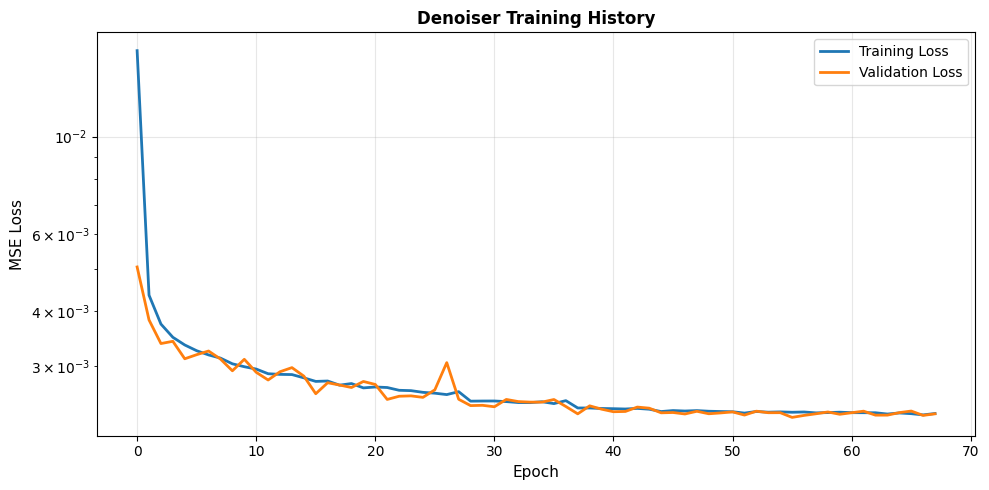

Saved training history to outputs/mnist/training_history.png


In [12]:
# ========================================================================
# MNIST: Train, Validate, and Save Denoiser
# ========================================================================
print("--- Training Blind Denoiser for MNIST ---")

# Create denoiser
mnist_denoiser = BF_CNN(depth=config.depth, n_channels=config.n_channels).to(config.device)

# Train denoiser
mnist_training_history = train_blind_denoiser(
    model=mnist_denoiser,
    config=config,
    train_loader=train_loader_mnist,
    val_loader=test_loader_mnist
)

# Create output directory
mnist_output_dir = config.save_dir / 'mnist'
mnist_output_dir.mkdir(parents=True, exist_ok=True)

# Save denoiser model
mnist_denoiser_path = mnist_output_dir / 'denoiser.pt'
torch.save(mnist_denoiser.state_dict(), mnist_denoiser_path)
print(f"✓ Denoiser saved to: {mnist_denoiser_path}\n")

# Plot training history
plot_training_history(mnist_training_history, mnist_output_dir)

--- Validating Denoiser Performance ---

--- Denoiser Test ---

Image 0 - Label: 7


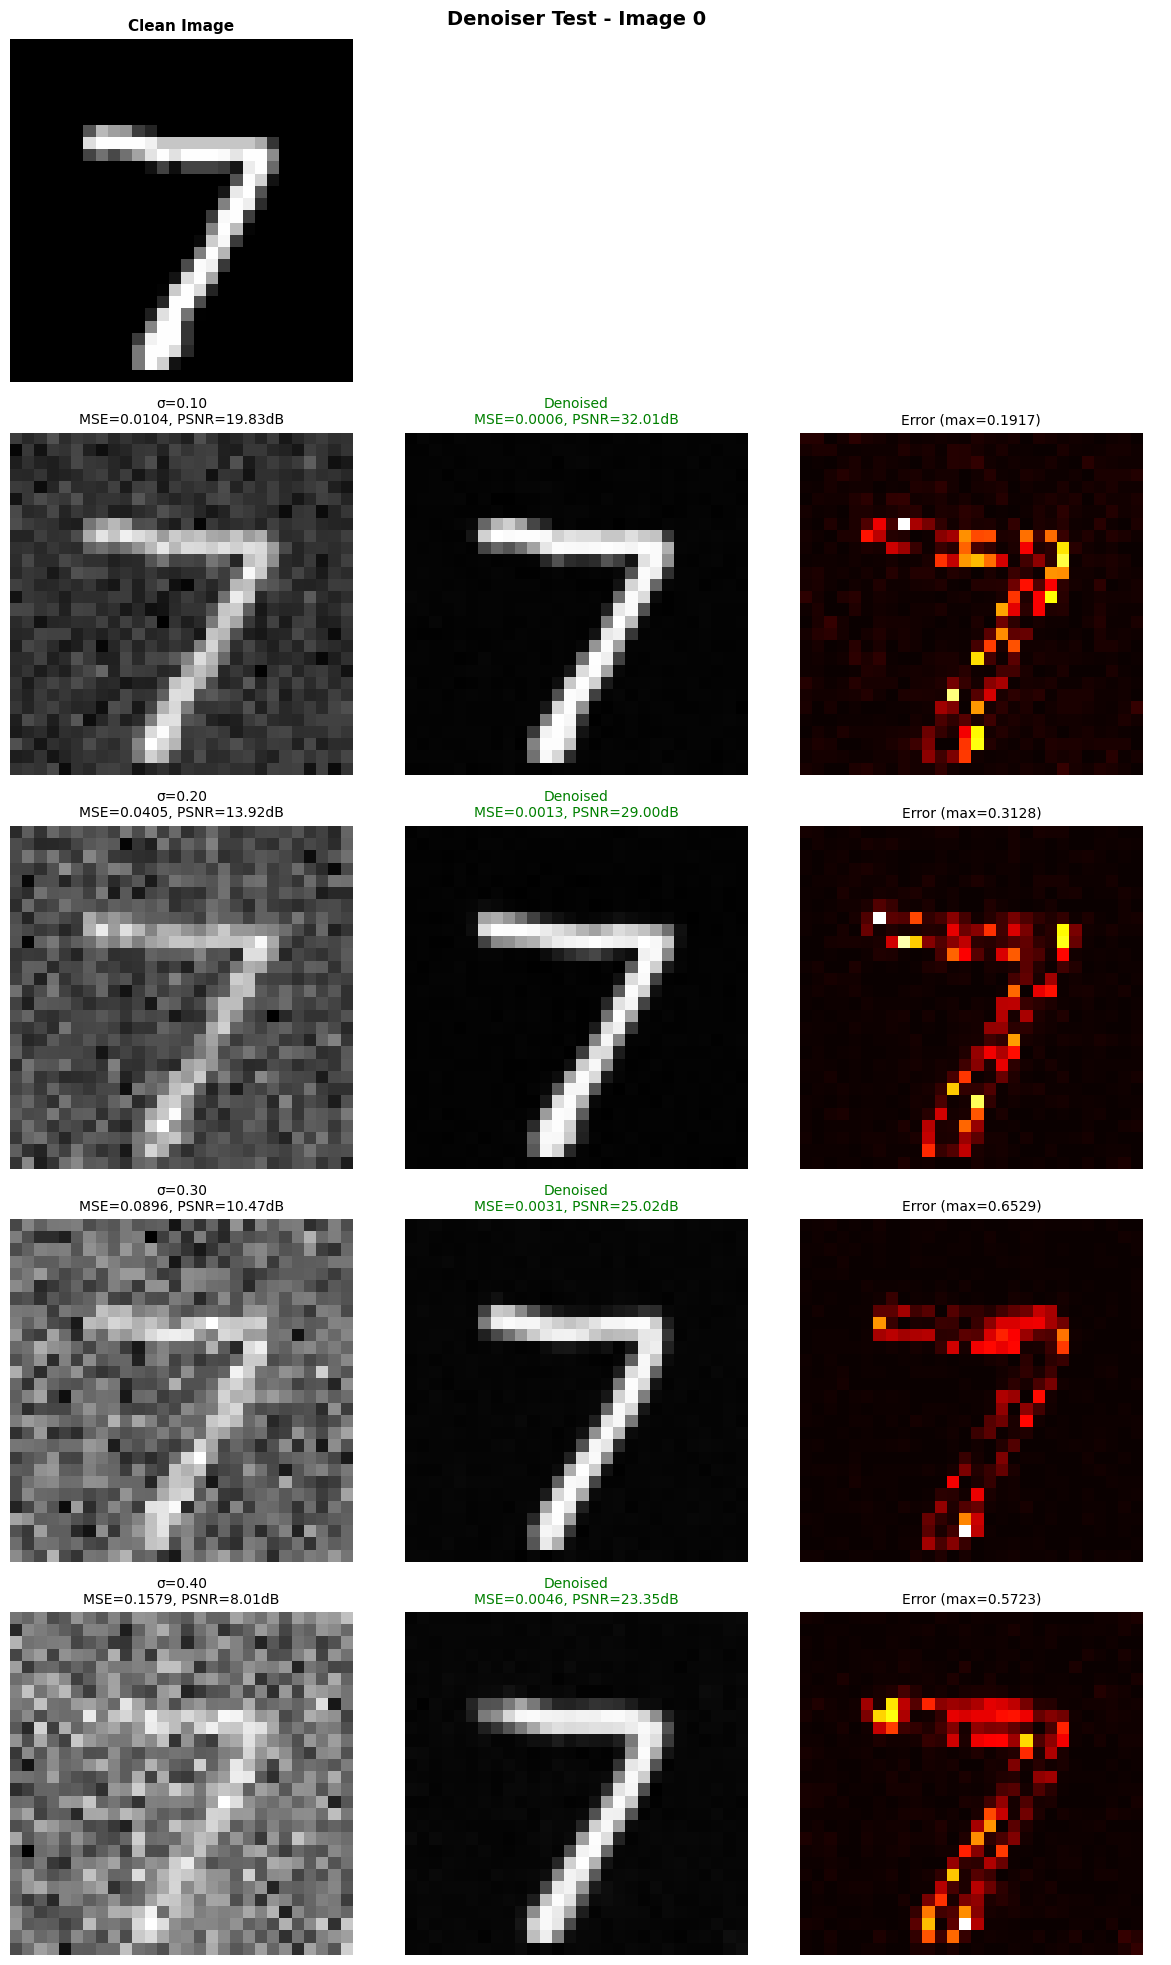

Image 50 - Label: 6


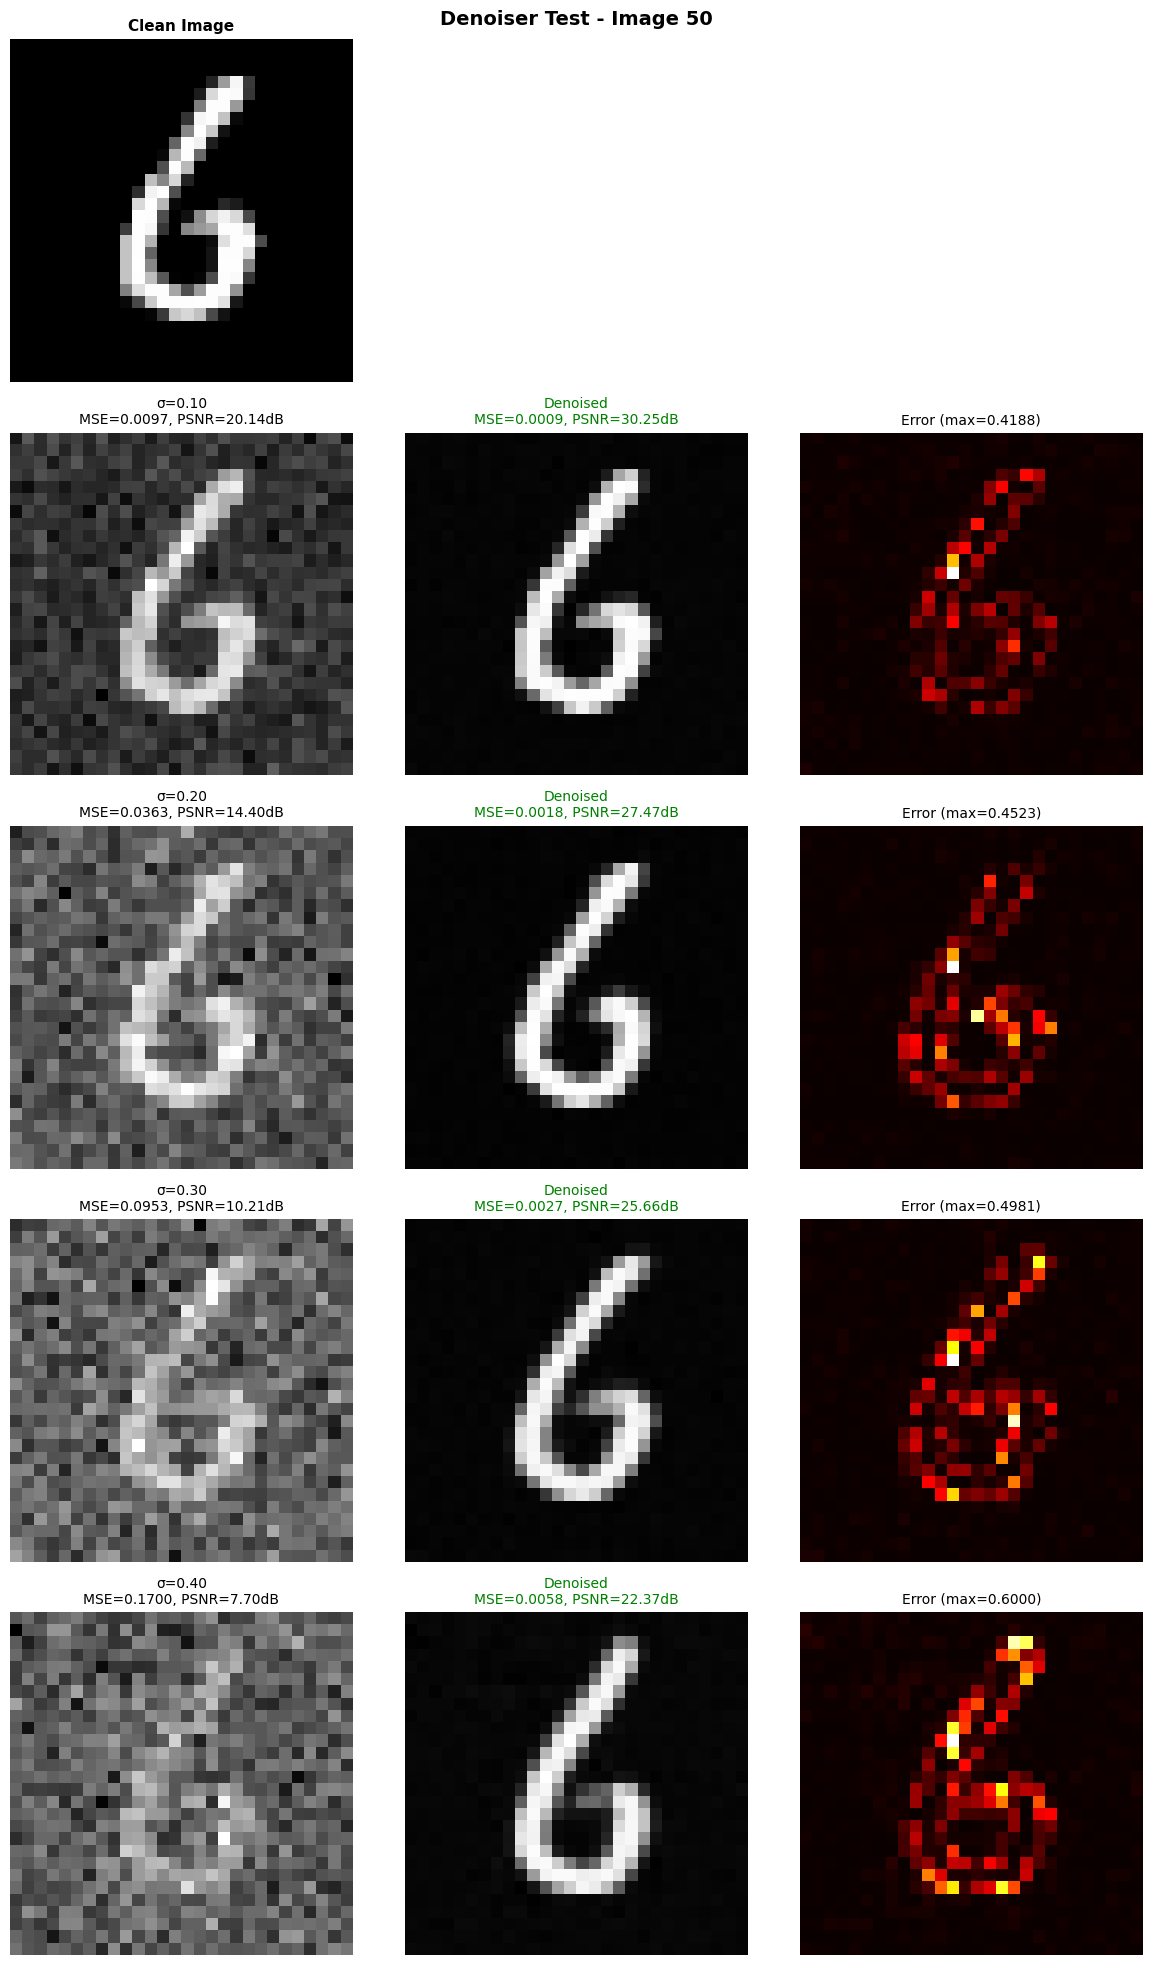

Image 100 - Label: 6


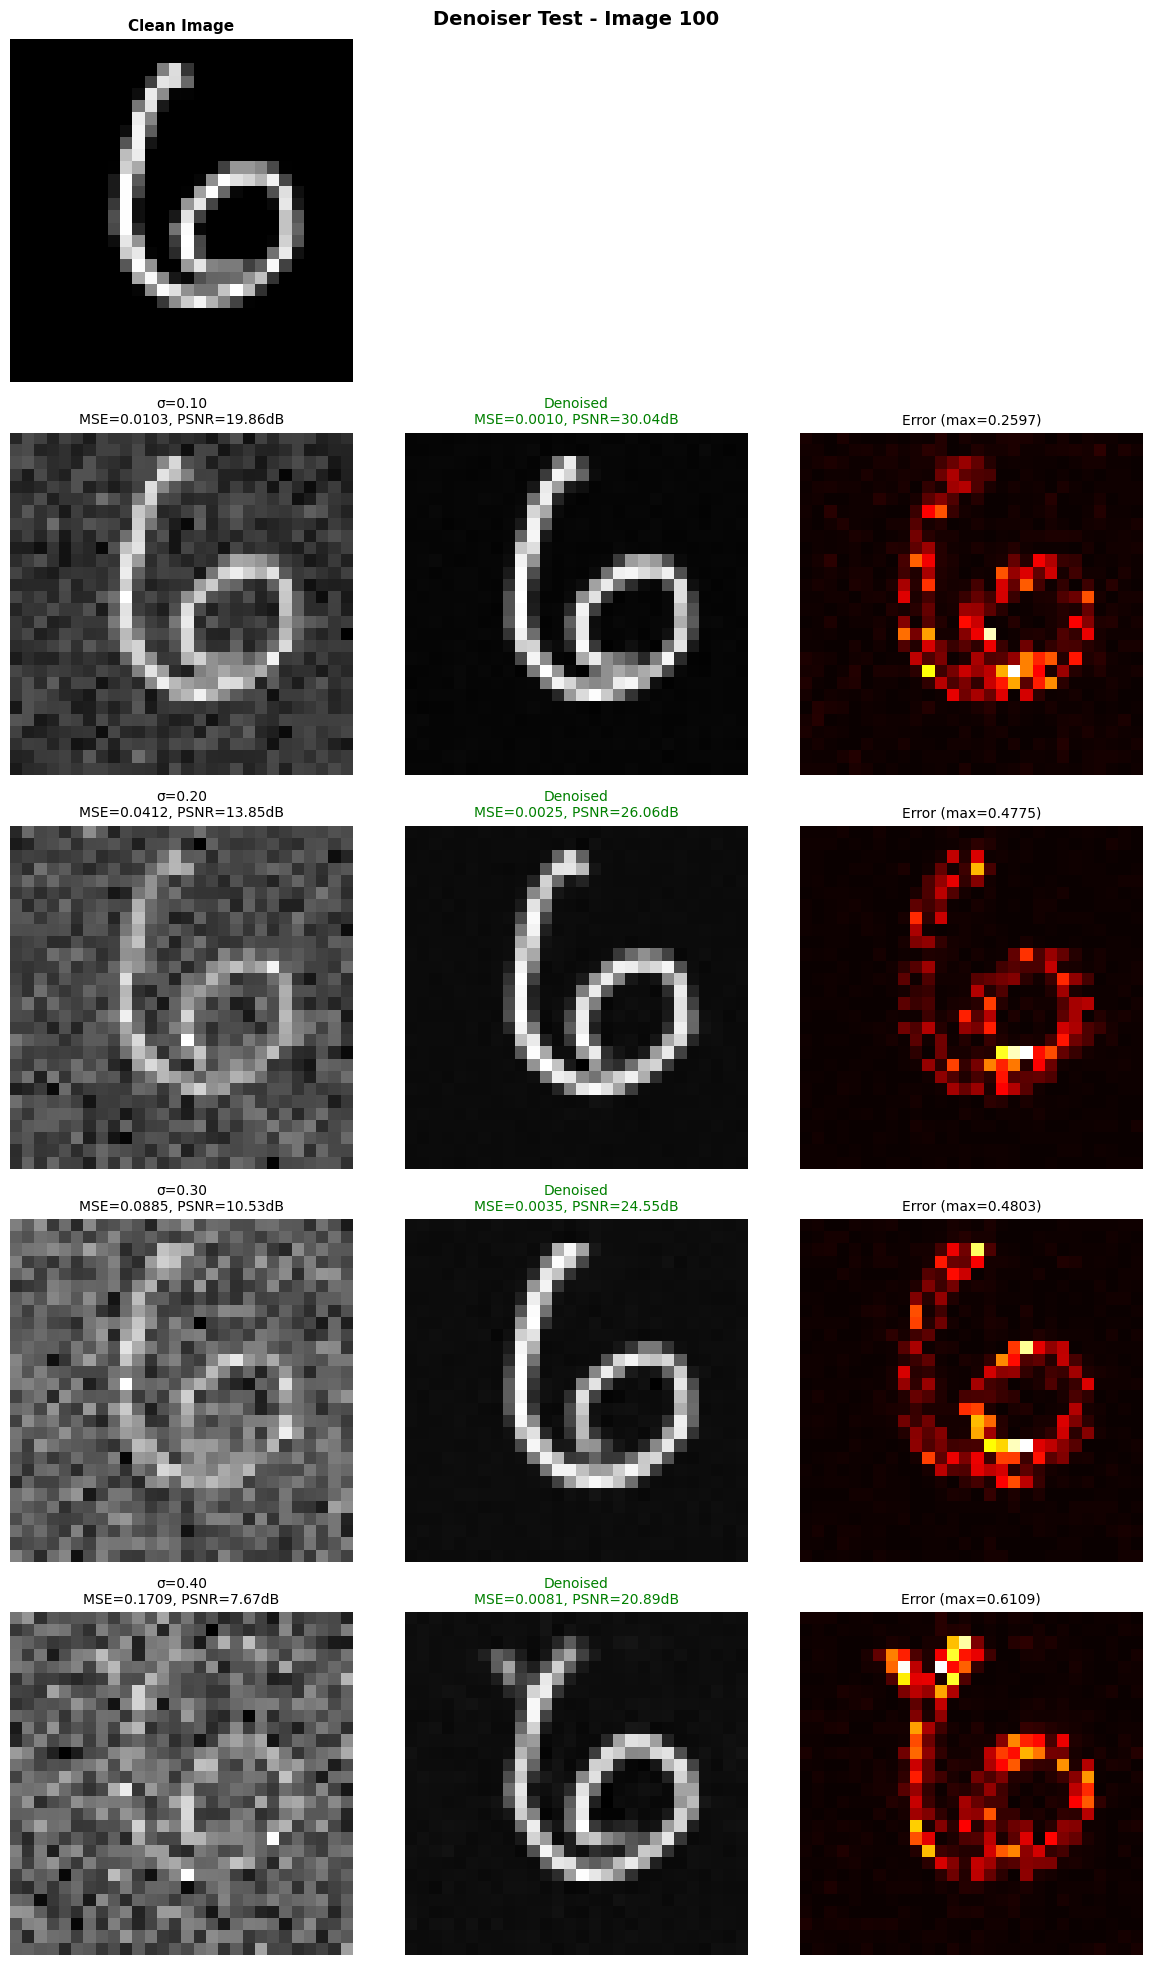

In [10]:
# ========================================================================
# MNIST: Validate Denoiser
# ========================================================================
print("--- Validating Denoiser Performance ---")

mnist_denoiser.eval()
visualize_denoiser_performance(
    model=mnist_denoiser,
    dataset=test_dataset_mnist,
    config=config,
    save_path=mnist_output_dir / 'denoiser_performance.png',
    test_indices=[0, 50, 100],
    noise_levels=[0.1, 0.2, 0.3, 0.4],
)


--- Testing Inpainting (Linear Inverse Problem) ---

Evaluating Inpainting Performance
Inpainting mask created: 12.8% of pixels masked


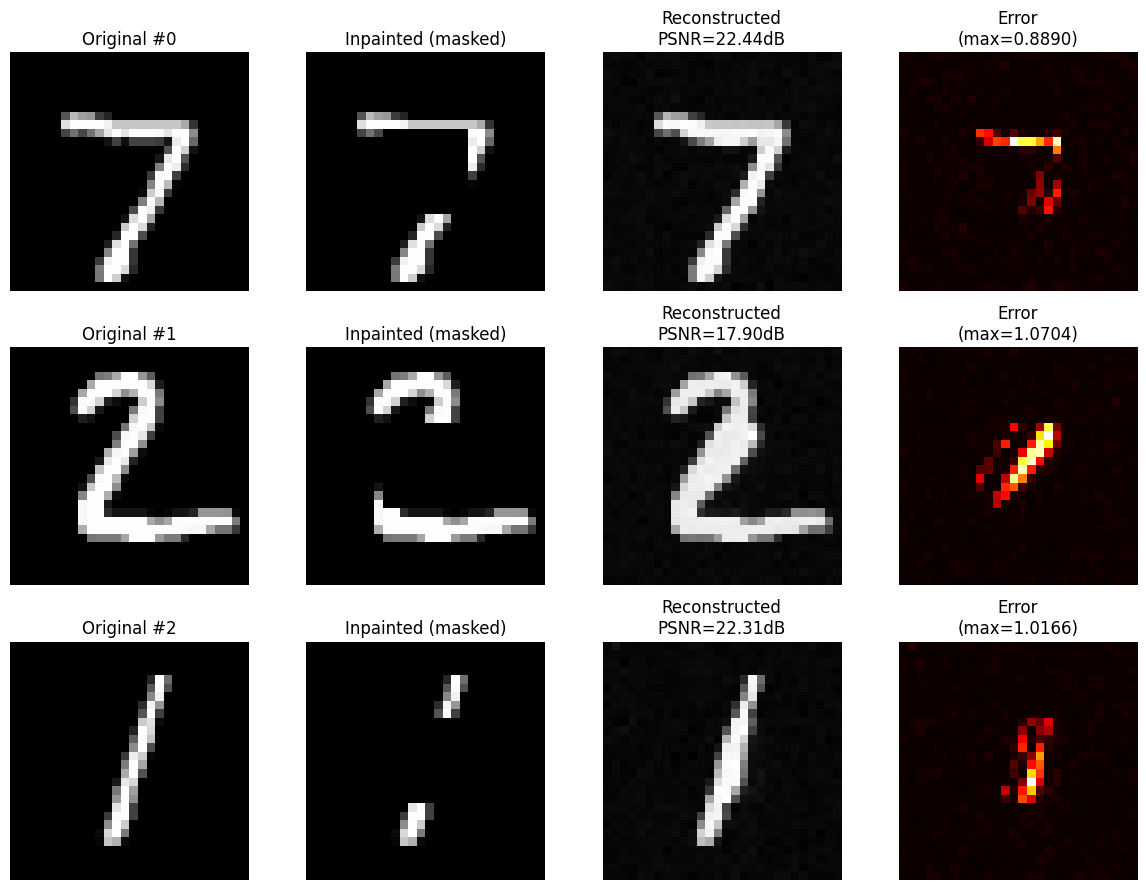

Saved inpainting results to outputs/mnist/inpainting_results.png/inpainting_results.png
Inpainting Results for MNIST:
  Mean PSNR: 20.88 dB
  Mean Iterations: 296.0



In [13]:
# ========================================================================
# MNIST: Test Inpainting
# ========================================================================
print("\n--- Testing Inpainting (Linear Inverse Problem) ---")

mnist_inpainting_results = evaluate_inpainting(
    denoiser=mnist_denoiser,
    val_dataset=test_dataset_mnist,
    config=config,
    num_test_images=3
)

visualize_inpainting_results(mnist_inpainting_results, mnist_output_dir / 'inpainting_results.png')

print(f"Inpainting Results for MNIST:")
print(f"  Mean PSNR: {mnist_inpainting_results['mean_psnr']:.2f} dB")
print(f"  Mean Iterations: {mnist_inpainting_results['mean_iterations']:.1f}\n")

In [6]:
# Reload denoiser for phase retrieval
mnist_denoiser = BF_CNN(depth=config.depth, n_channels=config.n_channels).to(config.device)

# Create output directory
mnist_output_dir = config.save_dir / 'mnist'
mnist_output_dir.mkdir(parents=True, exist_ok=True)
mnist_denoiser_path = mnist_output_dir / 'denoiser.pt'

mnist_denoiser.load_state_dict(torch.load(mnist_denoiser_path))
mnist_denoiser.eval()
print("✓ Denoiser loaded\n")

✓ Denoiser loaded



### MNIST: Gaussian Phase Retrieval

In [8]:
# ========================================================================
# MNIST: Gaussian Phase Retrieval - Hyperparameter Evaluation
# ========================================================================
print("="*80)
print("MNIST - Gaussian Phase Retrieval: Hyperparameter Evaluation")
print("="*80)

# Get Gaussian config
gaussian_config = config.get_gaussian_config()

# Parameter ranges for sweep
gaussian_param_ranges = {
    'beta': [0.01, 0.05, 0.1],
    'h0': [0.01, 0.05, 0.1],
    'sigma_L': [0.01],
}

# Run evaluation with parameter sweep
mnist_gaussian_results = run_gaussian_phase_retrieval_evaluation(
    denoiser=mnist_denoiser,
    val_dataset=test_dataset_mnist,
    config=gaussian_config,
    param_ranges=gaussian_param_ranges
)

# Find best configuration by PSNR
best_gaussian_config_name = max(
    mnist_gaussian_results.keys(),
    key=lambda k: mnist_gaussian_results[k]['mean_psnr']
)
best_gaussian_psnr =mnist_gaussian_results[best_gaussian_config_name]['mean_psnr']
best_gaussian_params = mnist_gaussian_results[best_gaussian_config_name]['params']

# Transform results for summary table
gaussian_summary_data = []
for config_name, res in mnist_gaussian_results.items():
    row = {
        **{key: f"{value:.3f}" if isinstance(value, float) else str(value) for key, value in res['params'].items()},
        'Mean PSNR (dB)': f"{res['mean_psnr']:.2f}",
        'Mean Iterations': f"{res['mean_iterations']:.1f}"
    }
    gaussian_summary_data.append(row)
gaussian_summary_df = pd.DataFrame(gaussian_summary_data).sort_values(by='Mean PSNR (dB)', ascending=False)
print("\nGaussian Phase Retrieval Hyperparameter Evaluation Summary:")
print(gaussian_summary_df.to_string(index=False))

print(f"\nBest Gaussian Config for MNIST:")
print(f"  {best_gaussian_config_name}")
print(f"  Parameters: {best_gaussian_params}")
print(f"  Mean PSNR: {best_gaussian_psnr:.3f} dB\n")

MNIST - Gaussian Phase Retrieval: Hyperparameter Evaluation

Gaussian Phase Retrieval Evaluation
Number of configurations: 9
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[1/9] PSNR: 44.3982
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[2/9] PSNR: 44.1281
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[3/9] PSNR: 44.1006
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[4/9] PSNR: 44.2937
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[5/9] PSNR: 44.1428
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[6/9] PSNR: 44.1633
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[7/9] PSNR: 43.5592
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[8/9] PSNR: 43.5165
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[9/9] PSNR: 42.8701

Gaussian Phase Retrieval Hyperparameter Evaluation Summary:
 beta    h0 sigma_L Mean PSNR (dB) Mean Iterations
0.010 0.010   0.010          44.40            70.7
0.050 0.010   0.010          44.29            77.1
0.050 0.100   0.010          44.16            80.8
0.050 0.050   0.010          44.14            66.1
0.010 0.050   0.010          44.13           122.4
0.010 0.100   0.010          44.10           266.4
0.100 0.010   0.010          43.56            83.2
0.100 0.050   0.010          43.52            65.0
0.100 0.100   0.010          42.87            74.2

Best Gaussian Config for MNIST:
  Config_00_beta=.0100_h0=.0100_sigma_L=.0100
  Parameters: {'beta': 0.01, 'h0': 0.01, 'sigma_L': 0.01}
  Mean PSNR: 44.398 dB



--- Gaussian PR: Final Evaluation with Best Config ---
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])
Saved reconstruction figure to outputs/mnist/gaussian_pr/gaussian_pr_result_0.png


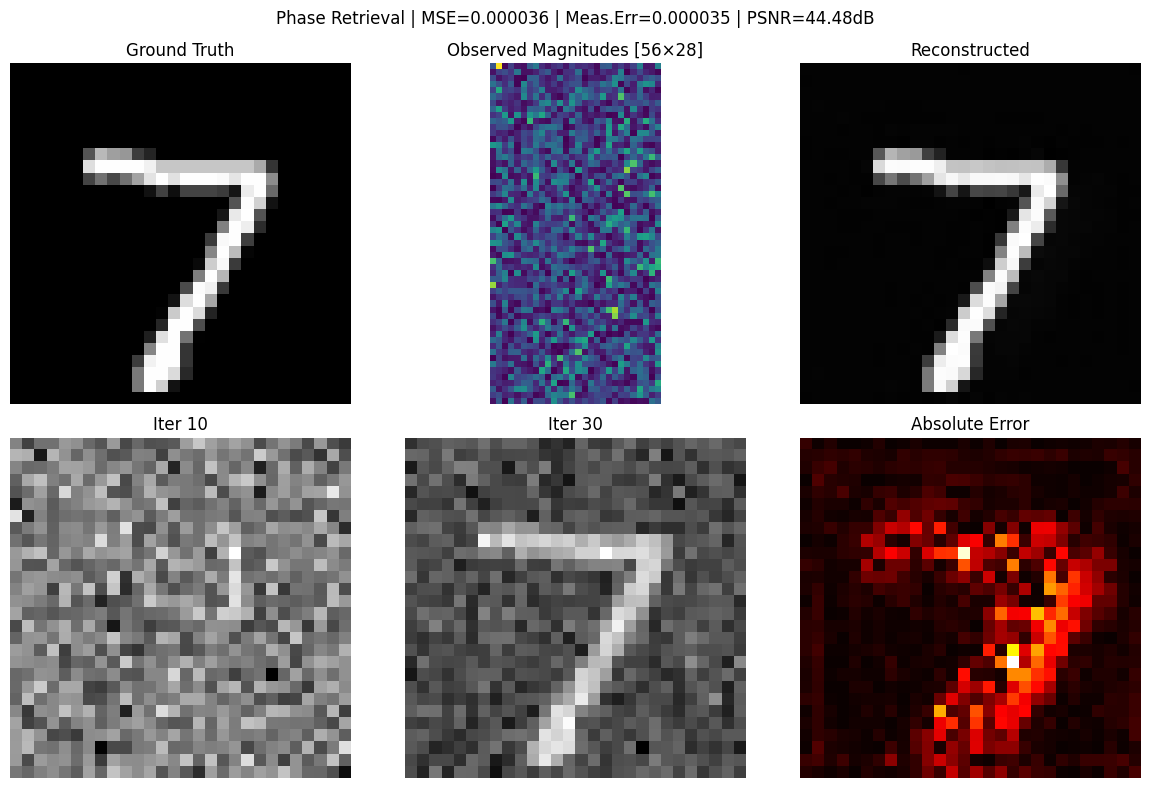

Saved convergence plot to outputs/mnist/gaussian_pr/mnist_gaussian_pr_convergence_0.png


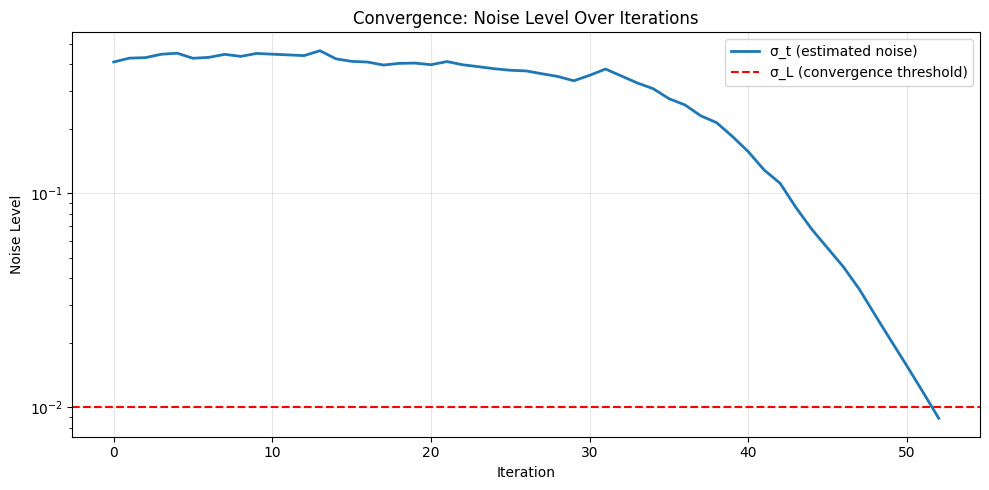

Saved reconstruction figure to outputs/mnist/gaussian_pr/gaussian_pr_result_1000.png


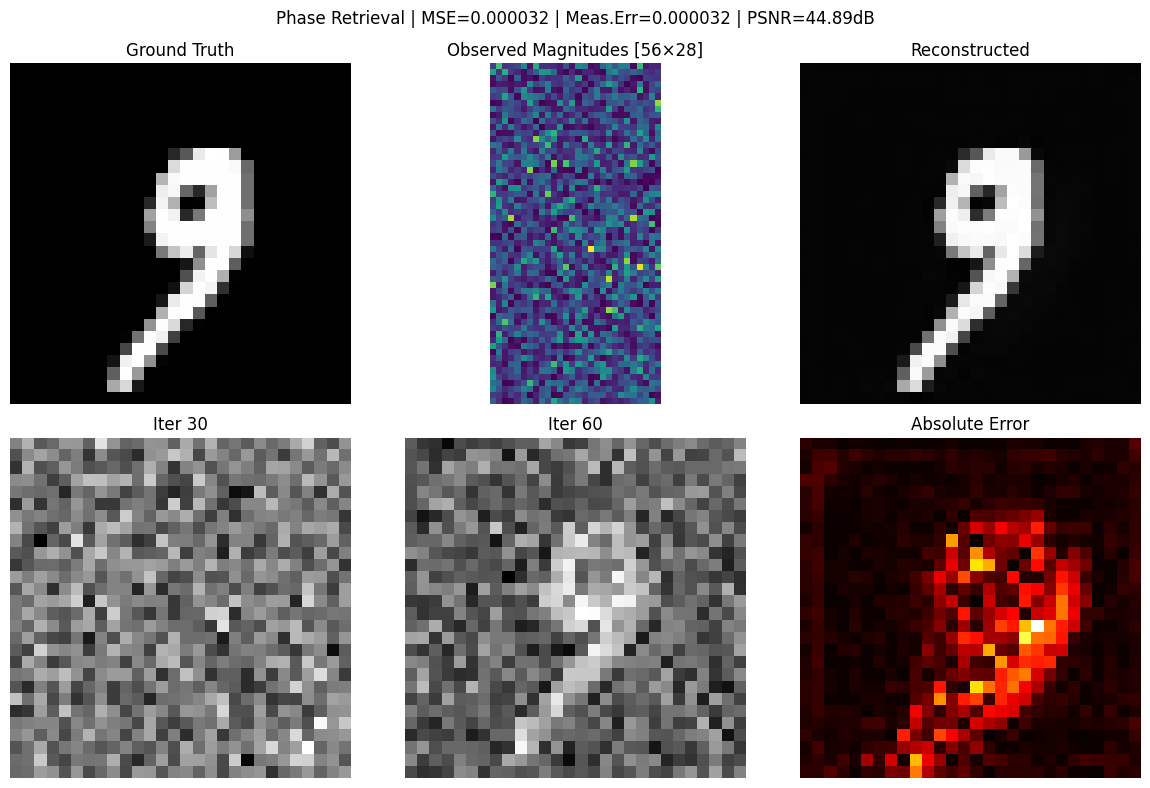

Saved convergence plot to outputs/mnist/gaussian_pr/mnist_gaussian_pr_convergence_1000.png


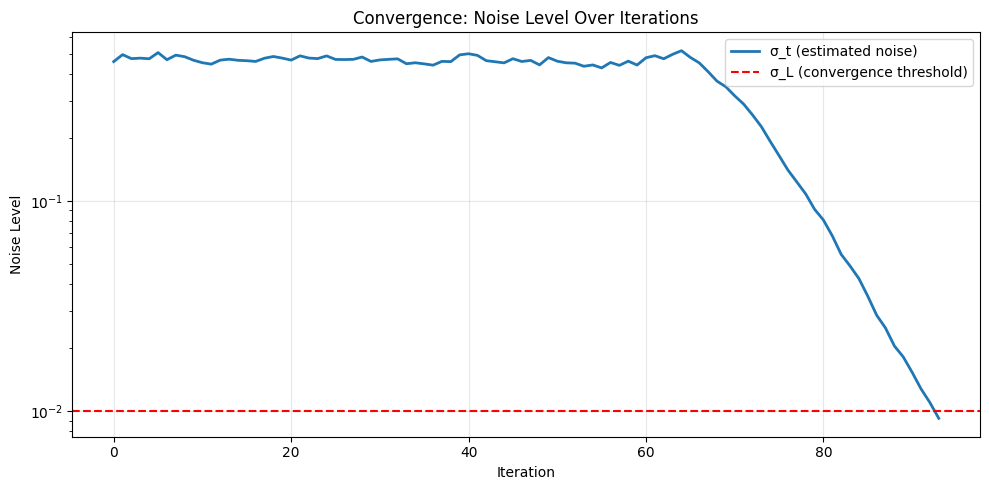

Saved reconstruction figure to outputs/mnist/gaussian_pr/gaussian_pr_result_2000.png


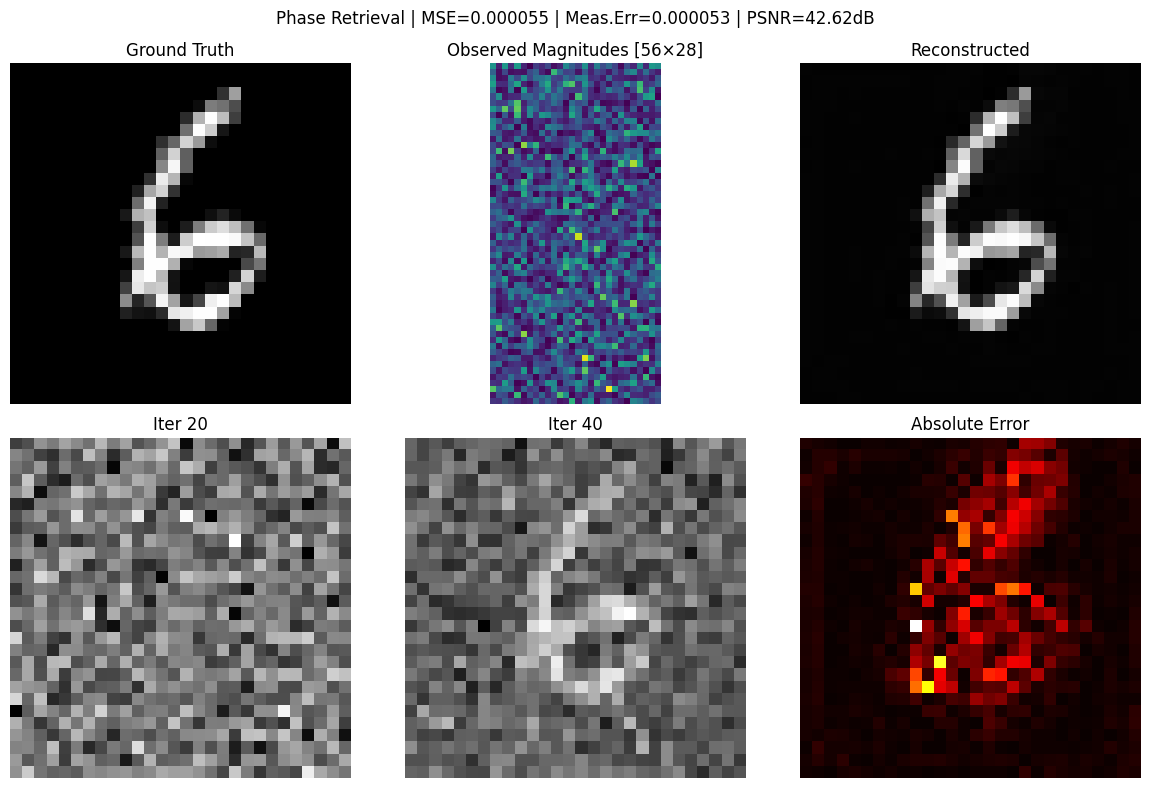

Saved convergence plot to outputs/mnist/gaussian_pr/mnist_gaussian_pr_convergence_2000.png


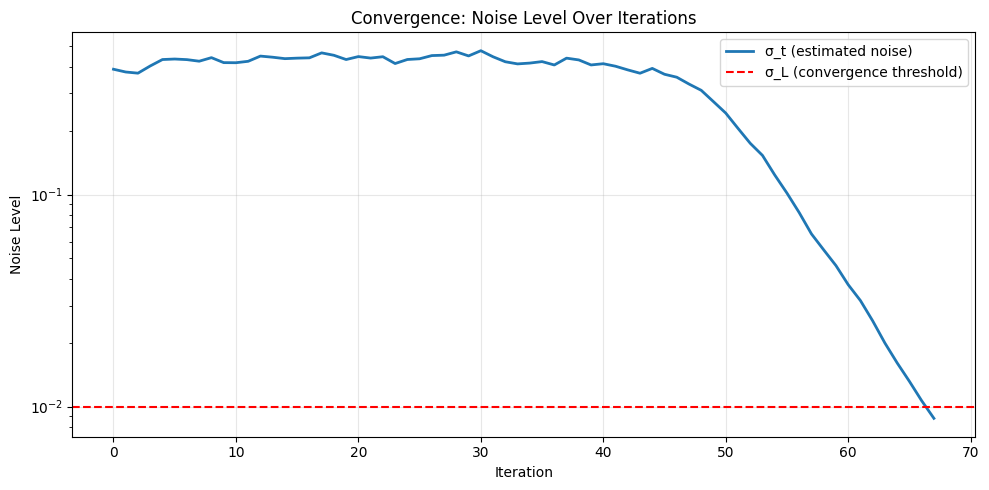


Gaussian Phase Retrieval Results for MNIST (Best Config):
  Mean MSE: 0.000041
  Mean PSNR: 44.00 dB



In [9]:
# ========================================================================
# MNIST: Gaussian Phase Retrieval - Final Evaluation with Best Config
# ========================================================================

# Run final evaluation with best config
print("--- Gaussian PR: Final Evaluation with Best Config ---")

gaussian_task = GaussianPhaseRetrievalTask(
    measurement_dim=gaussian_config.measurement_dim,
    image_dim=gaussian_config.n_pixels,
    device=gaussian_config.device
)

# Update config with best parameters
for key, value in best_gaussian_params.items():
    setattr(gaussian_config, key, value)

# Get test images
mnist_test_images = [0, 1000, 2000]

# Run phase retrieval on best 3 images and save visualizations
gaussian_pr_dir = mnist_output_dir / 'gaussian_pr'
gaussian_pr_dir.mkdir(parents=True, exist_ok=True)

mnist_gaussian_metrics = {'mse': [], 'psnr': []}

for idx in mnist_test_images:
    x_test, _ = test_dataset_mnist[idx]
    x_test_batch = x_test.view(-1).to(config.device)
    
    # Get measurements
    measurements = gaussian_task.get_magnitudes(x_test_batch)
    
    # Run phase retrieval with best config
    with torch.no_grad():
        x_recon, pr_results = phase_retrieval_with_gaussian_measurements(
            denoiser=mnist_denoiser,
            task=gaussian_task,
            measurements=measurements,
            config=gaussian_config
        )
        x_recon = x_recon.to(config.device)
    
    # Compute metrics
    eval_metrics = evaluate_reconstruction(x_recon, x_test_batch, gaussian_task, measurements)
    mnist_gaussian_metrics['mse'].append(eval_metrics['mse_image'])
    mnist_gaussian_metrics['psnr'].append(eval_metrics['psnr'])

    # Save visualization for this image
    visualize_reconstruction_results(
        x_test_batch.cpu(),
        x_recon.cpu(),
        measurement=measurements.cpu(),
        trajectory=pr_results['intermediates'],
        metrics=eval_metrics,
        save_path=gaussian_pr_dir / f'gaussian_pr_result_{idx}.png'
    )

    visualize_convergence(
        pr_results['sigma_trajectory'],
        gaussian_pr_dir / f'mnist_gaussian_pr_convergence_{idx}.png',
        sigma_L=gaussian_config.sigma_L
    )

print(f"\nGaussian Phase Retrieval Results for MNIST (Best Config):")
print(f"  Mean MSE: {np.mean(mnist_gaussian_metrics['mse']):.6f}")
print(f"  Mean PSNR: {np.mean(mnist_gaussian_metrics['psnr']):.2f} dB\n")

### MNIST: Fourier Phase Retrieval

In [7]:
# ========================================================================
# MNIST: Fourier Phase Retrieval - Hyperparameter Evaluation
# ========================================================================
print("="*80)
print("MNIST - Fourier Phase Retrieval: Hyperparameter Evaluation")
print("="*80)

# Get Fourier config
fourier_config = config.get_fourier_config()

# Parameter ranges for sweep (Fourier uses different step size)
fourier_param_ranges = {
    'beta': [0.01, 0.05, 0.1],
    'h0': [0.01, 0.05, 0.1],
    'sigma_L': [0.01],
}

# Run evaluation with parameter sweep
mnist_fourier_results = run_fourier_phase_retrieval_evaluation(
    denoiser=mnist_denoiser,
    val_dataset=test_dataset_mnist,
    config=fourier_config,
    param_ranges=fourier_param_ranges
)

# Find best configuration by PSNR
best_fourier_config_name = max(
    mnist_fourier_results.keys(),
    key=lambda k: mnist_fourier_results[k]['mean_psnr']
)
best_fourier_psnr = mnist_fourier_results[best_fourier_config_name]['mean_psnr']
best_fourier_params = mnist_fourier_results[best_fourier_config_name]['params']

# Transform results for summary table
fourier_summary_data = []
for config_name, res in mnist_fourier_results.items():
    row = {
        **{key: f"{value:.3f}" if isinstance(value, float) else str(value) for key, value in res['params'].items()},
        'Mean PSNR (dB)': f"{res['mean_psnr']:.2f}",
        'Mean Iterations': f"{res['mean_iterations']:.1f}"
    }
    fourier_summary_data.append(row)
fourier_summary_df = pd.DataFrame(fourier_summary_data).sort_values(by='Mean PSNR (dB)', ascending=False)
print("\nFourier Phase Retrieval Hyperparameter Evaluation Summary:")
print(fourier_summary_df.to_string(index=False))

print(f"\nBest Fourier Config for MNIST:")
print(f"  {best_fourier_config_name}")
print(f"  Parameters: {best_fourier_params}")
print(f"  Mean PSNR: {best_fourier_psnr:.3f} dB\n")

MNIST - Fourier Phase Retrieval: Hyperparameter Evaluation

Fourier Phase Retrieval Evaluation
Number of configurations: 9
Fourier Task: Image 28x28, Padded to 56x56
Measurements M: 3136, Image N: 784


[1/9] PSNR: 21.6689


[2/9] PSNR: 24.3305


[3/9] PSNR: 24.4042


[4/9] PSNR: 20.9188


[5/9] PSNR: 22.2618


[6/9] PSNR: 23.1875


[7/9] PSNR: 20.2965


[8/9] PSNR: 21.1310


[9/9] PSNR: 21.5929

Fourier Phase Retrieval Hyperparameter Evaluation Summary:
 beta    h0 sigma_L Mean PSNR (dB) Mean Iterations
0.010 0.100   0.010          24.40           278.7
0.010 0.050   0.010          24.33           280.3
0.050 0.100   0.010          23.19           259.5
0.050 0.050   0.010          22.26           280.8
0.010 0.010   0.010          21.67           318.1
0.100 0.100   0.010          21.59           256.0
0.100 0.050   0.010          21.13           275.9
0.050 0.010   0.010          20.92           321.5
0.100 0.010   0.010          20.30           314.8

Best Fourier Config for MNIST:
  Config_02_beta=.0100_h0=.1000_sigma_L=.0100
  Parameters: {'beta': 0.01, 'h0': 0.1, 'sigma_L': 0.01}
  Mean PSNR: 24.404 dB



--- Fourier PR: Final Evaluation with Best Config ---
Fourier Task: Image 28x28, Padded to 56x56
Measurements M: 3136, Image N: 784
Saved reconstruction figure to outputs/mnist/fourier_pr/mnist_fourier_pr_0.png


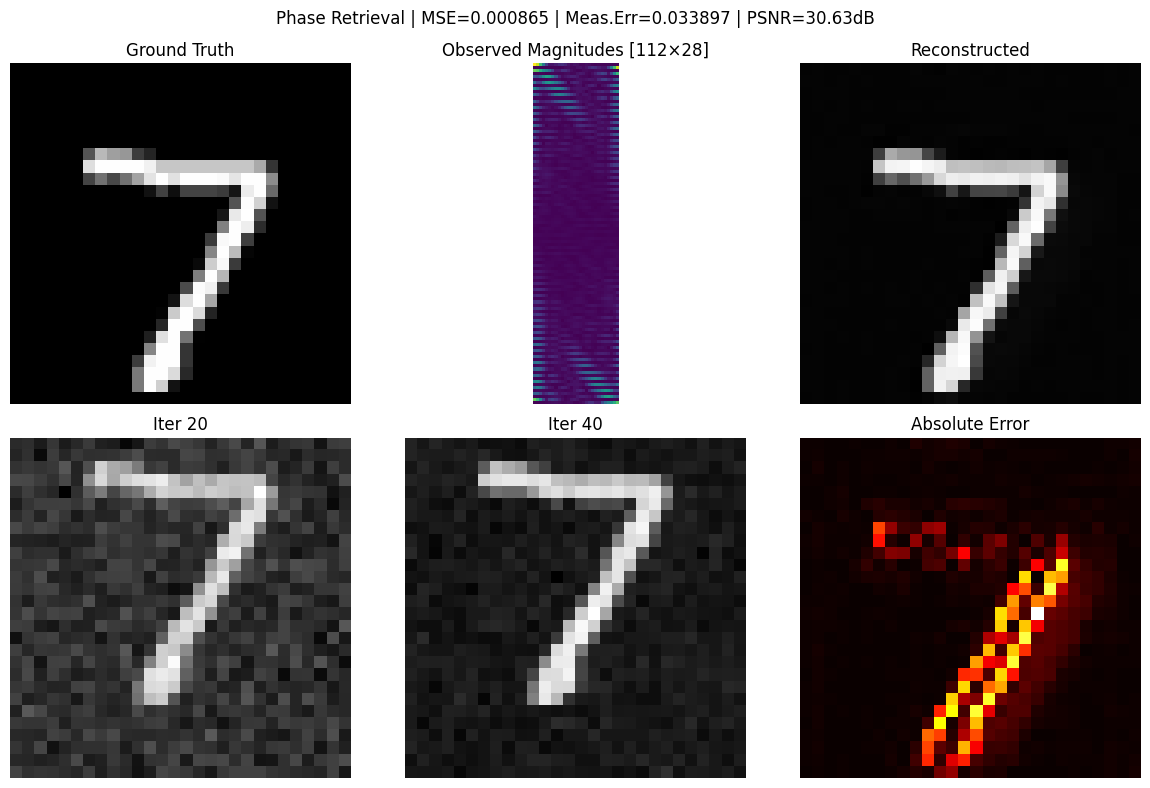

Saved convergence plot to outputs/mnist/fourier_pr/mnist_fourier_pr_convergence_0.png


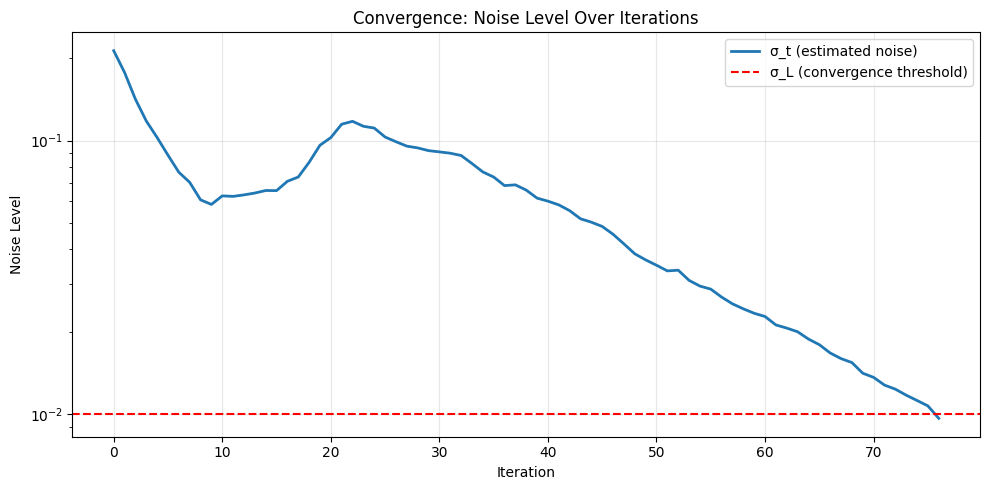

Saved reconstruction figure to outputs/mnist/fourier_pr/mnist_fourier_pr_1000.png


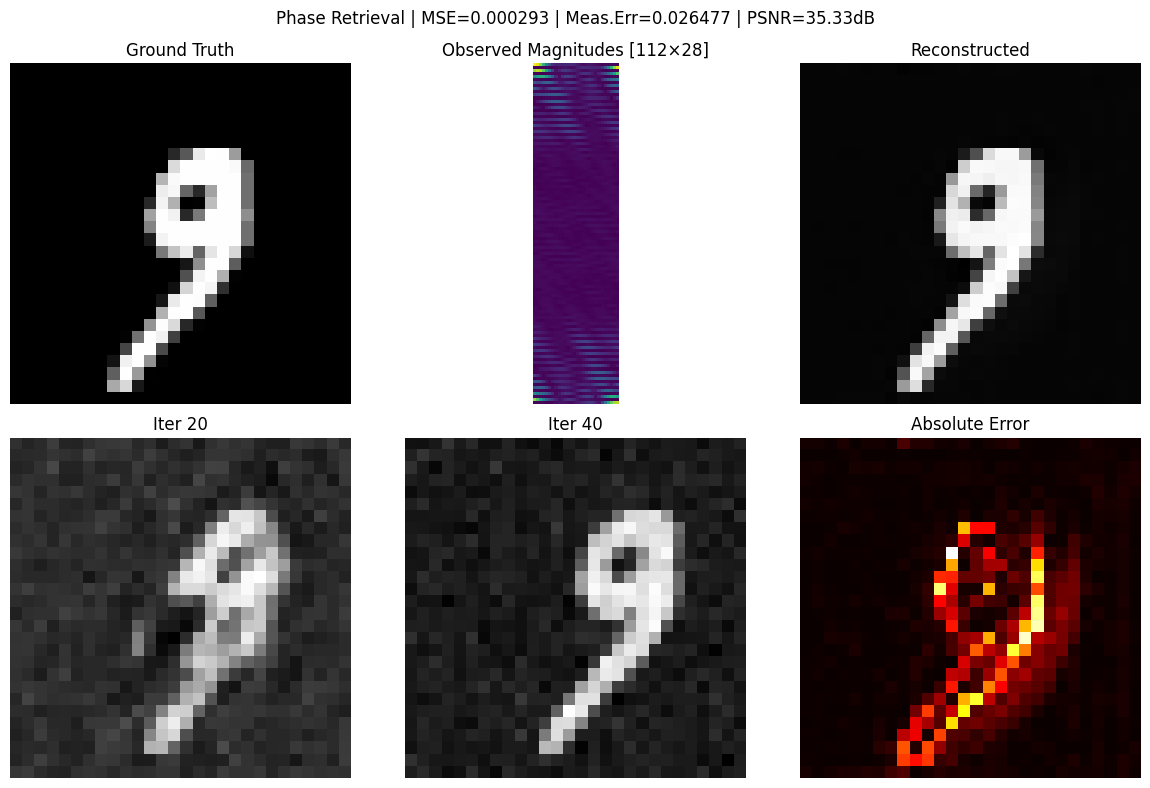

Saved convergence plot to outputs/mnist/fourier_pr/mnist_fourier_pr_convergence_1000.png


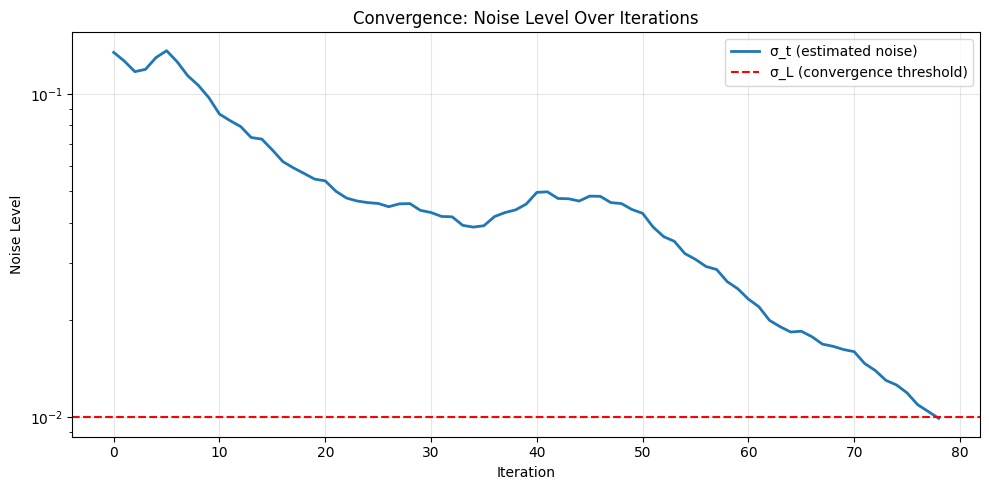

Saved reconstruction figure to outputs/mnist/fourier_pr/mnist_fourier_pr_2000.png


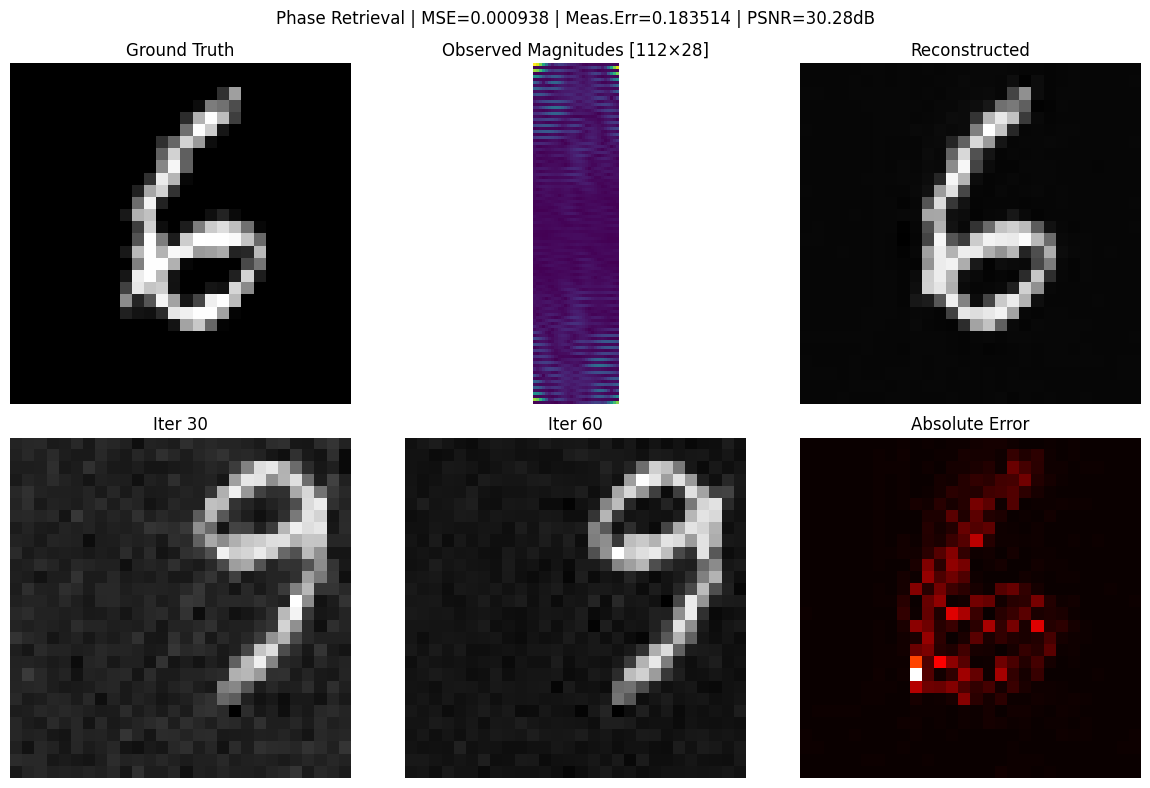

Saved convergence plot to outputs/mnist/fourier_pr/mnist_fourier_pr_convergence_2000.png


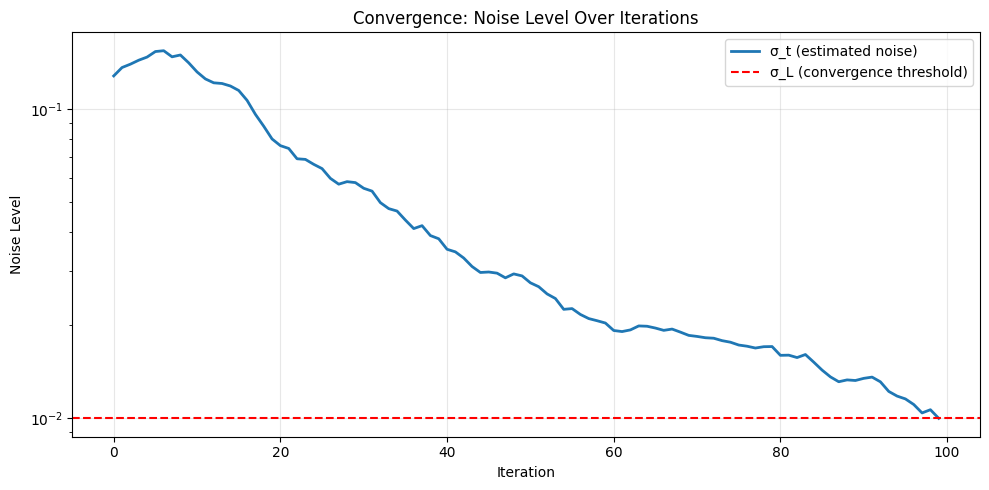


Fourier Phase Retrieval Results for MNIST (Best Config):
  Mean MSE: 0.000699
  Mean PSNR: 32.08 dB



In [10]:
# ========================================================================
# MNIST: Fourier Phase Retrieval - Final Evaluation with Best Config
# ========================================================================

# Run final evaluation with best config
print("--- Fourier PR: Final Evaluation with Best Config ---")

fourier_task = FourierPhaseRetrievalTask(
    image_size=fourier_config.image_size,
    oversample_ratio=fourier_config.oversample_ratio,
    device=fourier_config.device
)

# Update config with best parameters
for key, value in best_fourier_params.items():
    setattr(fourier_config, key, value)

# Get test images
mnist_test_images_fourier = [0, 1000, 2000]

# Run phase retrieval on best 3 images and save visualizations
fourier_pr_dir = mnist_output_dir / 'fourier_pr'
fourier_pr_dir.mkdir(parents=True, exist_ok=True)

mnist_fourier_metrics = {'mse': [], 'psnr': []}

for idx in mnist_test_images_fourier:
    x_test, _ = test_dataset_mnist[idx]
    x_test_batch = x_test.view(-1).to(config.device)
    
    # Get measurements
    measurements = fourier_task.get_magnitudes(x_test_batch)
    
    # Run phase retrieval with best config
    with torch.no_grad():
        x_recon, pr_results = phase_retrieval_with_fourier_measurements(
            denoiser=mnist_denoiser,
            task=fourier_task,
            measurements=measurements,
            config=fourier_config
        )
        x_recon = x_recon.to(config.device)
    
    # Align to handle ambiguities
    x_aligned, _ = align_fourier_reconstruction(
        x_recon=x_recon,
        x_test=x_test_batch,
        image_size=fourier_config.image_size
    )
    
    # Compute metrics
    eval_metrics = evaluate_reconstruction(x_aligned, x_test_batch, fourier_task, measurements)
    mnist_fourier_metrics['mse'].append(eval_metrics['mse_image'])
    mnist_fourier_metrics['psnr'].append(eval_metrics['psnr'])

    # Save visualization for this image
    visualize_reconstruction_results(
        x_test_batch.cpu(),
        x_aligned.cpu(),
        measurement=measurements.cpu(),
        trajectory=pr_results['intermediates'],
        metrics=eval_metrics,
        save_path=fourier_pr_dir / f'mnist_fourier_pr_{idx}.png'
    )

    visualize_convergence(
        pr_results['sigma_trajectory'],
        fourier_pr_dir / f'mnist_fourier_pr_convergence_{idx}.png',
        sigma_L=fourier_config.sigma_L
    )

print(f"\nFourier Phase Retrieval Results for MNIST (Best Config):")
print(f"  Mean MSE: {np.mean(mnist_fourier_metrics['mse']):.6f}")
print(f"  Mean PSNR: {np.mean(mnist_fourier_metrics['psnr']):.2f} dB\n")

# Store results
all_results.append({
    'dataset': 'MNIST',
    'task': 'Fourier PR',
    'mse': np.mean(mnist_fourier_metrics['mse']),
    'psnr': np.mean(mnist_fourier_metrics['psnr']),
    'config': best_fourier_params
})

# FashionMNIST Dataset

In [11]:
# Load FashionMNIST dataset
print("="*80)
print("PROCESSING: FashionMNIST Dataset")
print("="*80)

train_dataset_fashion = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_fashion = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader_fashion = DataLoader(train_dataset_fashion, batch_size=config.batch_size_train, shuffle=True, num_workers=0)
test_loader_fashion = DataLoader(test_dataset_fashion, batch_size=config.batch_size_test, shuffle=False, num_workers=0)

print(f"FashionMNIST loaded: {len(train_dataset_fashion)} train, {len(test_dataset_fashion)} test samples\n")

PROCESSING: FashionMNIST Dataset
FashionMNIST loaded: 60000 train, 10000 test samples



--- Training Blind Denoiser for FashionMNIST ---
Starting denoiser training...
Number of parameters: 481,216


Validation Epoch 1/70: 100%|██████████| 79/79 [00:01<00:00, 48.79it/s]


Epoch   1/70 - Train Loss: 0.01553337 - Val Loss: 0.00705138 - LR: 1.00e-03


Validation Epoch 2/70: 100%|██████████| 79/79 [00:01<00:00, 49.32it/s]


Epoch   2/70 - Train Loss: 0.00645149 - Val Loss: 0.00591587 - LR: 1.00e-03


...

Epoch  68/70 - Train Loss: 0.00404347 - Val Loss: 0.00414074 - LR: 6.25e-05


Validation Epoch 69/70: 100%|██████████| 79/79 [00:01<00:00, 48.59it/s]


Epoch  69/70 - Train Loss: 0.00402849 - Val Loss: 0.00407463 - LR: 6.25e-05


Validation Epoch 70/70: 100%|██████████| 79/79 [00:01<00:00, 48.57it/s]


Epoch  70/70 - Train Loss: 0.00401850 - Val Loss: 0.00398849 - LR: 6.25e-05
Denoiser training complete!
✓ Denoiser saved to: outputs/fashionmnist/denoiser.pt



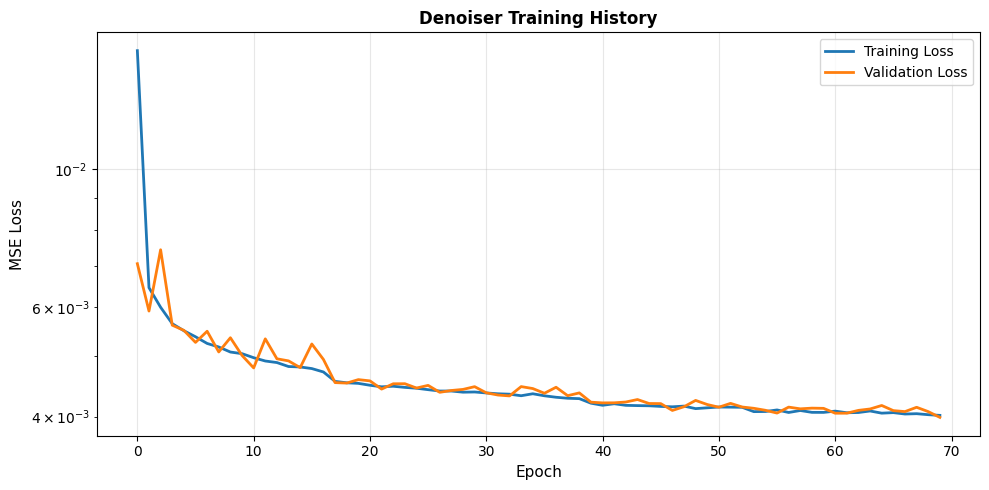

Saved training history to outputs/fashionmnist/training_history.png


In [23]:
# ========================================================================
# FashionMNIST: Train, Validate, and Save Denoiser
# ========================================================================
print("--- Training Blind Denoiser for FashionMNIST ---")

# Create denoiser
fashion_denoiser = BF_CNN(depth=config.depth, n_channels=config.n_channels).to(config.device)

# Train denoiser
fashion_training_history = train_blind_denoiser(
    model=fashion_denoiser,
    config=config,
    train_loader=train_loader_fashion,
    val_loader=test_loader_fashion
)

# Create output directory
fashion_output_dir = config.save_dir / 'fashionmnist'
fashion_output_dir.mkdir(parents=True, exist_ok=True)

# Save denoiser model
fashion_denoiser_path = fashion_output_dir / 'denoiser.pt'
torch.save(fashion_denoiser.state_dict(), fashion_denoiser_path)
print(f"✓ Denoiser saved to: {fashion_denoiser_path}\n")

# Plot training history
plot_training_history(fashion_training_history, fashion_output_dir)

--- Validating Denoiser Performance ---

--- Denoiser Test ---

Image 0 - Label: 9


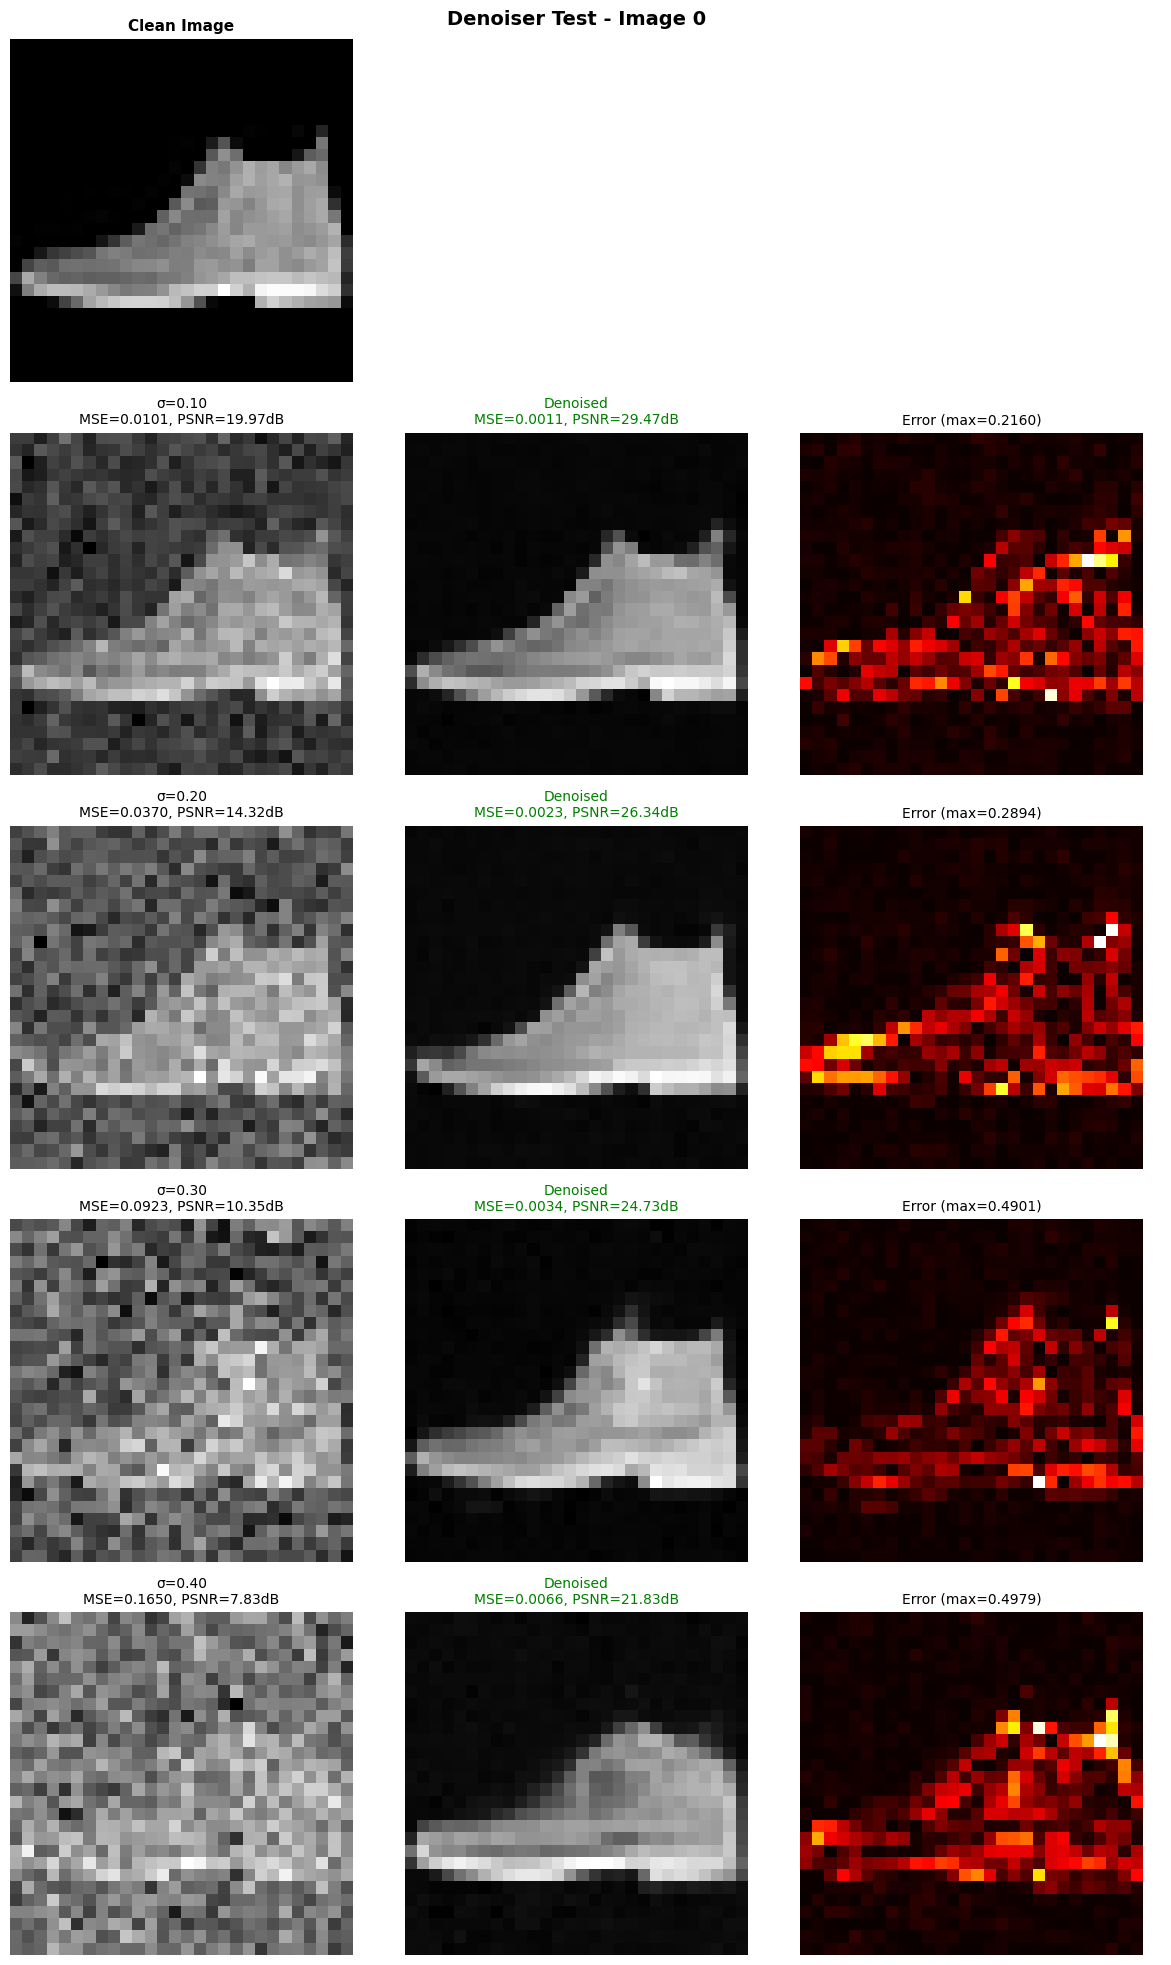

Image 50 - Label: 4


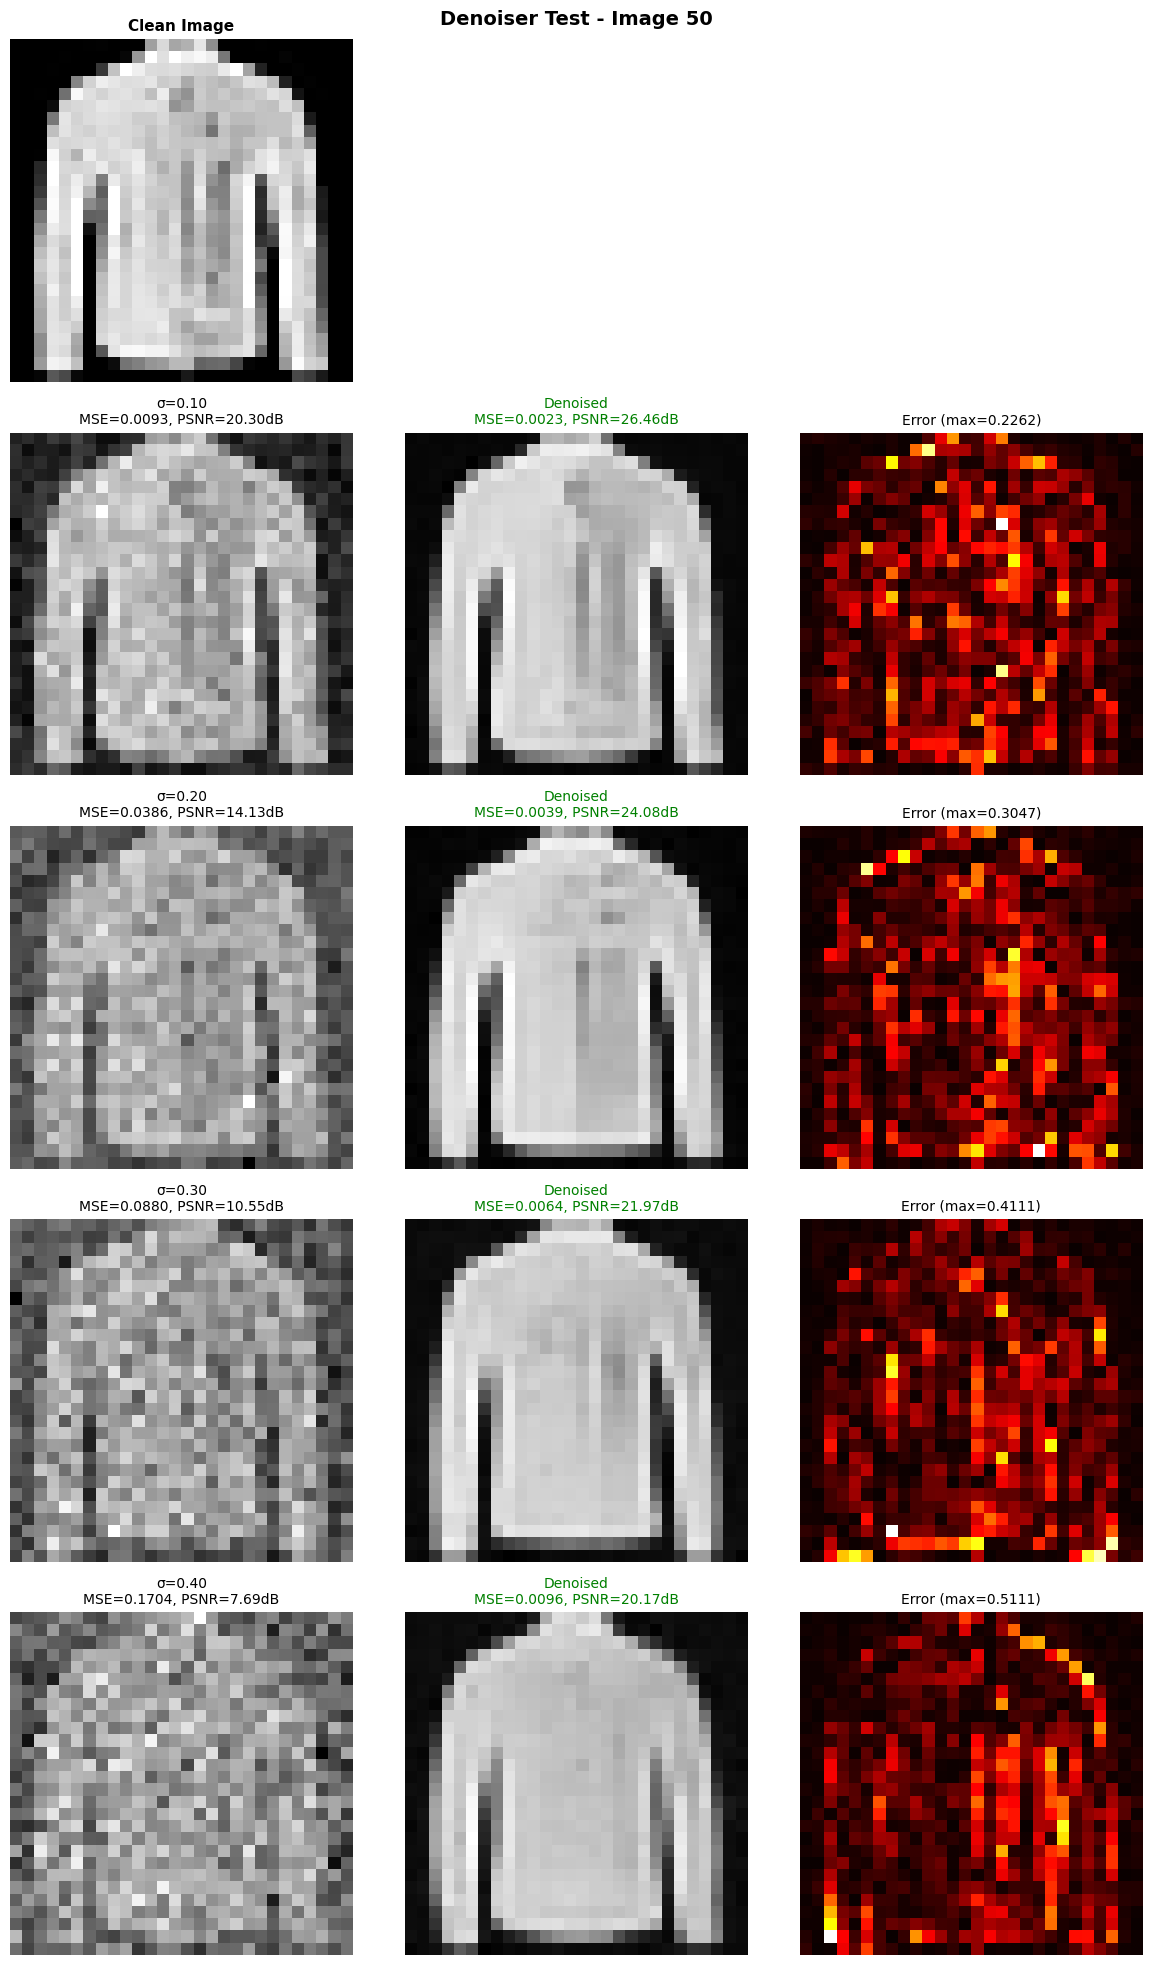

Image 100 - Label: 3


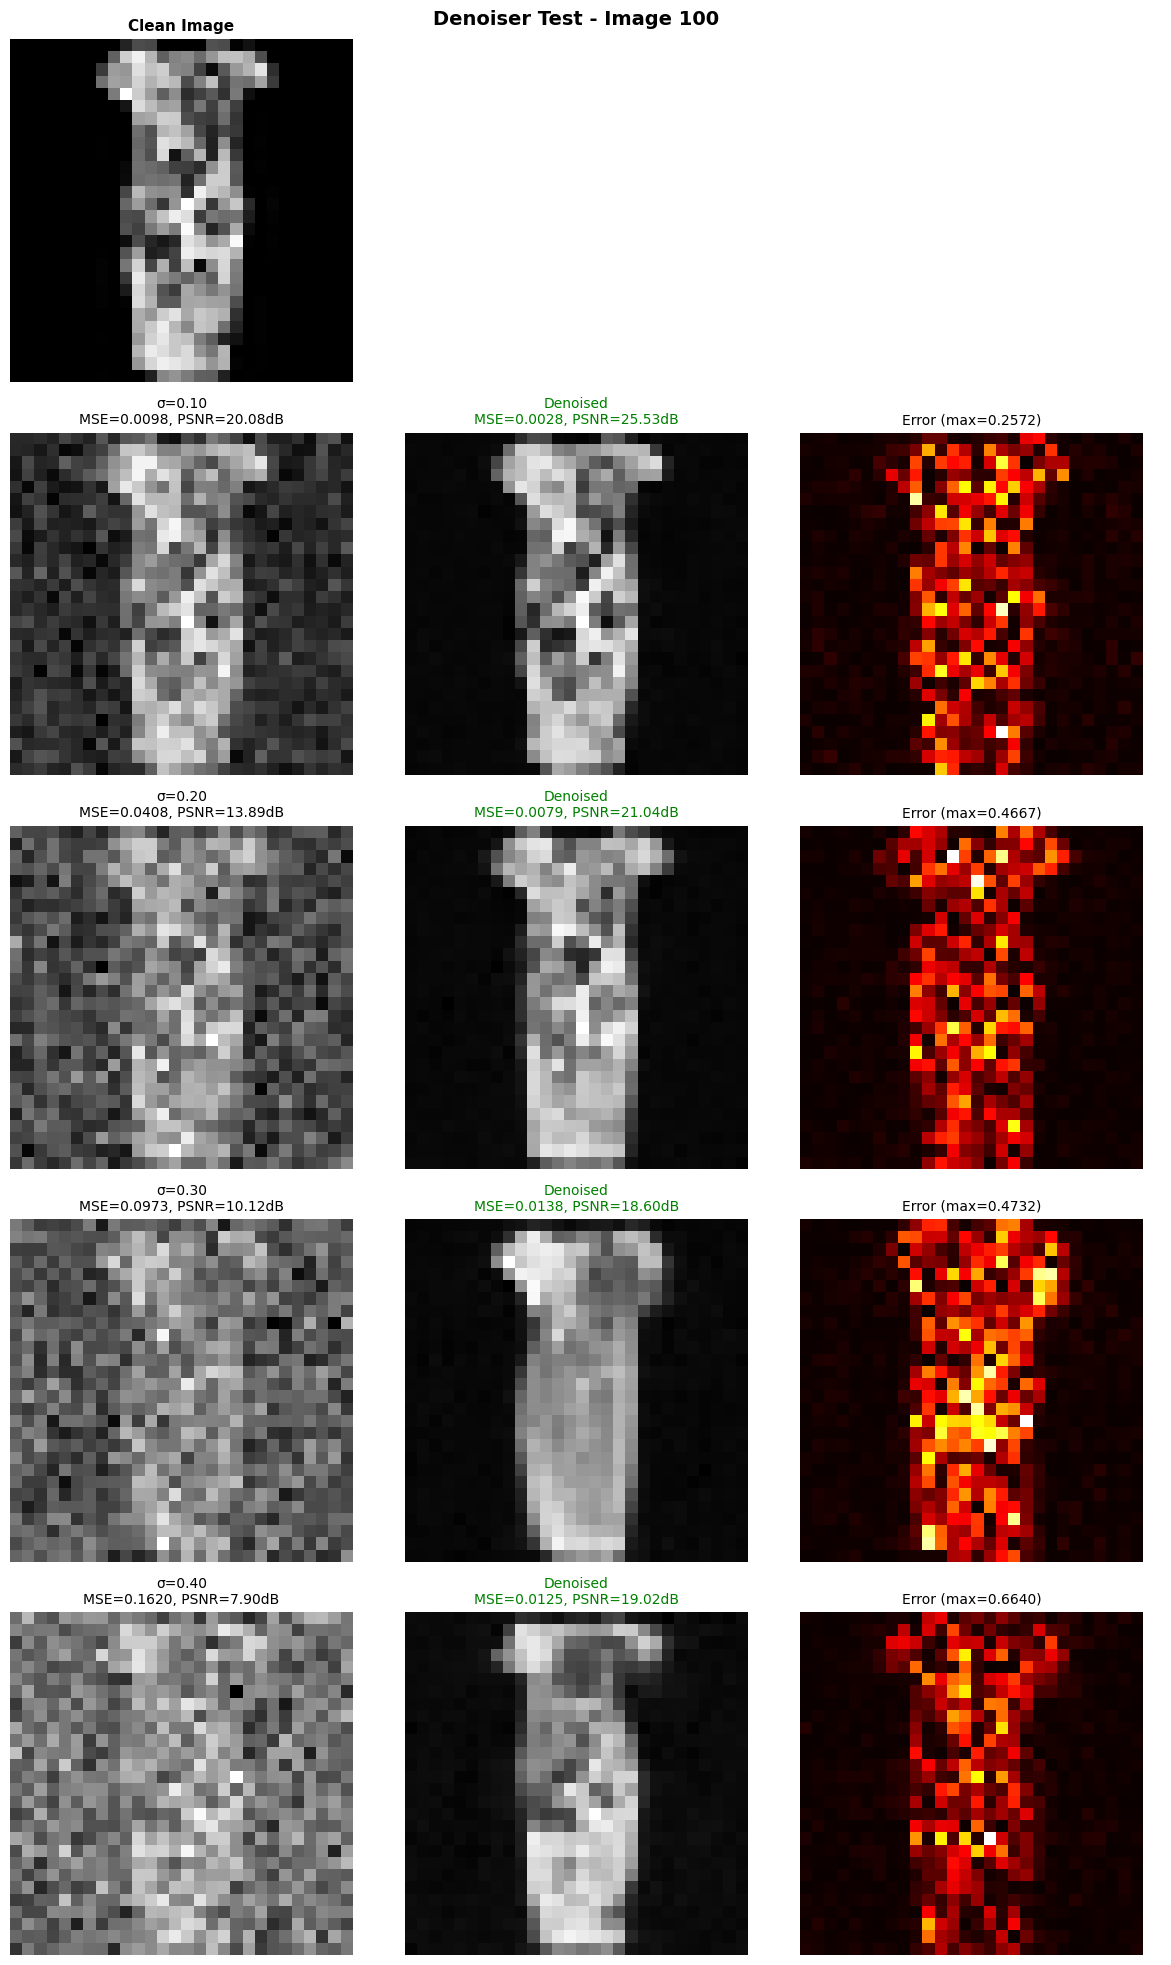

In [24]:
# ========================================================================
# FashionMNIST: Validate Denoiser
# ========================================================================
print("--- Validating Denoiser Performance ---")

fashion_denoiser.eval()
visualize_denoiser_performance(
    model=fashion_denoiser,
    dataset=test_dataset_fashion,
    config=config,
    save_path=fashion_output_dir / 'denoiser_performance.png',
    test_indices=[0, 50, 100],
    noise_levels=[0.1, 0.2, 0.3, 0.4],
)


--- Testing Inpainting (Linear Inverse Problem) ---

Evaluating Inpainting Performance
Inpainting mask created: 12.8% of pixels masked


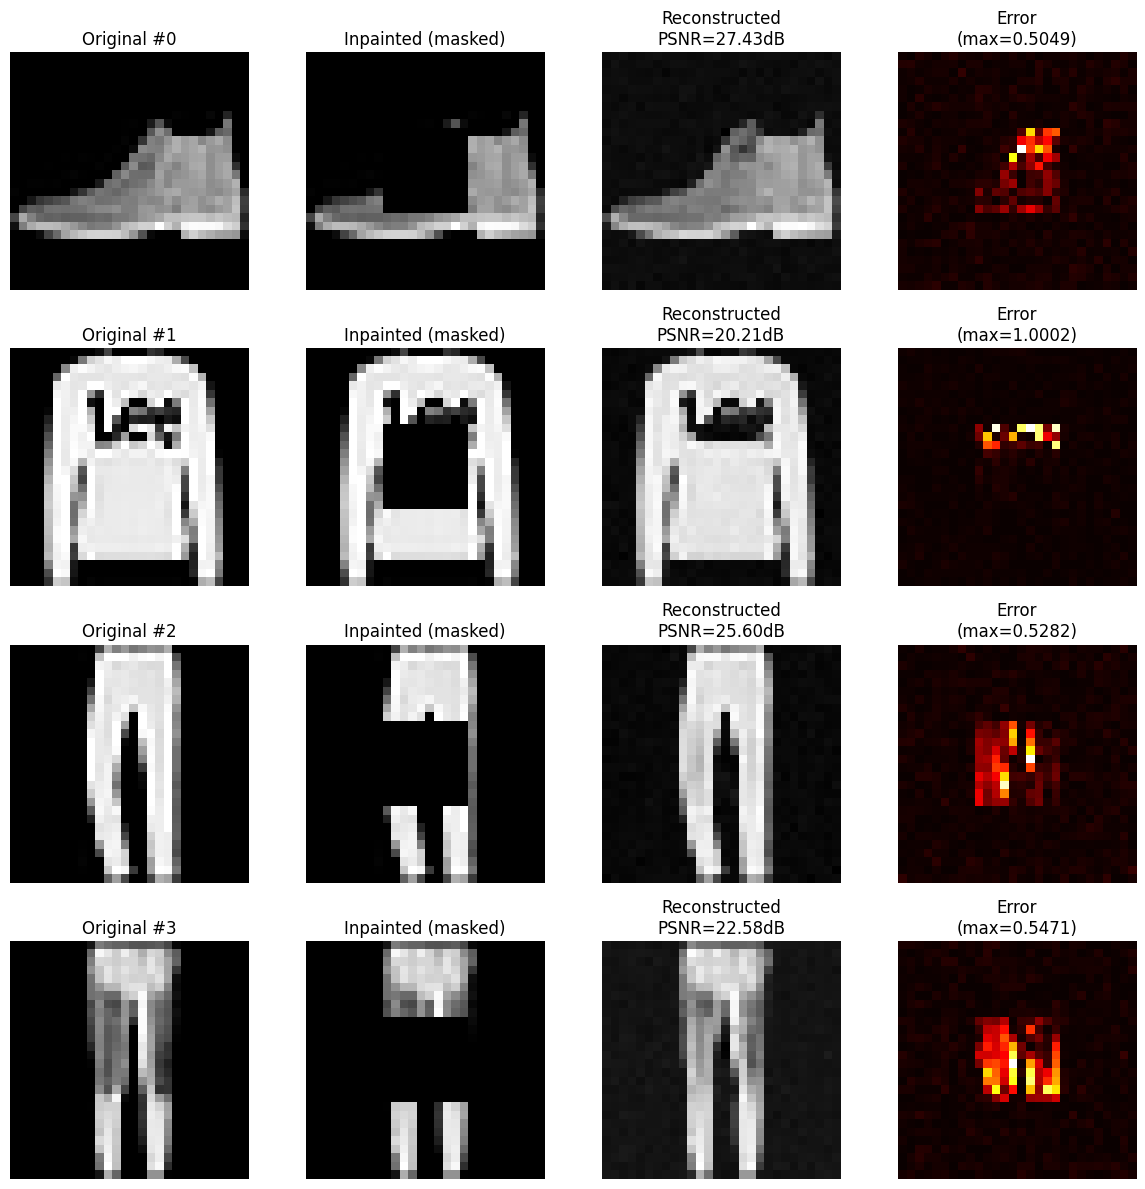

Saved inpainting results to outputs/fashionmnist/inpainting_results.png/inpainting_results.png
Inpainting Results for FashionMNIST:
  Mean PSNR: 23.95 dB
  Mean Iterations: 244.5



In [30]:
# ========================================================================
# FashionMNIST: Test Inpainting
# ========================================================================
print("\n--- Testing Inpainting (Linear Inverse Problem) ---")

fashion_inpainting_results = evaluate_inpainting(
    denoiser=fashion_denoiser,
    val_dataset=test_dataset_fashion,
    config=config,
    num_test_images=4
)

visualize_inpainting_results(fashion_inpainting_results, fashion_output_dir / 'inpainting_results.png')

print(f"Inpainting Results for FashionMNIST:")
print(f"  Mean PSNR: {fashion_inpainting_results['mean_psnr']:.2f} dB")
print(f"  Mean Iterations: {fashion_inpainting_results['mean_iterations']:.1f}\n")

In [12]:
# Reload denoiser for phase retrieval
fashion_denoiser = BF_CNN(depth=config.depth, n_channels=config.n_channels).to(config.device)

# Create output directory
fashion_output_dir = config.save_dir / 'fashionmnist'
fashion_output_dir.mkdir(parents=True, exist_ok=True)
fashion_denoiser_path = fashion_output_dir / 'denoiser.pt'

# Reload denoiser for phase retrieval
fashion_denoiser.load_state_dict(torch.load(fashion_denoiser_path))
fashion_denoiser.eval()
print("✓ Denoiser loaded\n")

✓ Denoiser loaded



### FashionMNIST: Gaussian Phase Retrieval

In [7]:
# ========================================================================
# FashionMNIST: Gaussian Phase Retrieval - Hyperparameter Evaluation
# ========================================================================
print("="*80)
print("FashionMNIST - Gaussian Phase Retrieval: Hyperparameter Evaluation")
print("="*80)

# Get Gaussian config
gaussian_config_fashion = config.get_gaussian_config()

# Parameter ranges for sweep
gaussian_param_ranges_fashion = {
    'beta': [0.01, 0.05, 0.1],
    'h0': [0.01, 0.05, 0.1],
    'sigma_L': [0.01],
}

# Run evaluation with parameter sweep
fashion_gaussian_results = run_gaussian_phase_retrieval_evaluation(
    denoiser=fashion_denoiser,
    val_dataset=test_dataset_fashion,
    config=gaussian_config_fashion,
    param_ranges=gaussian_param_ranges_fashion
)

# Find best configuration by PSNR
best_gaussian_config_name_fashion = max(
    fashion_gaussian_results.keys(),
    key=lambda k: fashion_gaussian_results[k]['mean_psnr']
)
best_gaussian_psnr_fashion = fashion_gaussian_results[best_gaussian_config_name_fashion]['mean_psnr']
best_gaussian_params_fashion = fashion_gaussian_results[best_gaussian_config_name_fashion]['params']

# Transform results for summary table
gaussian_summary_data_fashion = []
for config_name, res in fashion_gaussian_results.items():
    row = {
        **{key: f"{value:.3f}" if isinstance(value, float) else str(value) for key, value in res['params'].items()},
        'Mean PSNR (dB)': f"{res['mean_psnr']:.2f}",
        'Mean Iterations': f"{res['mean_iterations']:.1f}"
    }
    gaussian_summary_data_fashion.append(row)
gaussian_summary_df_fashion = pd.DataFrame(gaussian_summary_data_fashion).sort_values(by='Mean PSNR (dB)', ascending=False)
print("\nGaussian Phase Retrieval Hyperparameter Evaluation Summary:")
print(gaussian_summary_df_fashion.to_string(index=False))

print(f"\nBest Gaussian Config for FashionMNIST:")
print(f"  {best_gaussian_config_name_fashion}")
print(f"  Parameters: {best_gaussian_params_fashion}")
print(f"  Mean PSNR: {best_gaussian_psnr_fashion:.3f} dB\n")

FashionMNIST - Gaussian Phase Retrieval: Hyperparameter Evaluation

Gaussian Phase Retrieval Evaluation
Number of configurations: 9
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[1/9] PSNR: 41.5749
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[2/9] PSNR: 41.0752
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[3/9] PSNR: 40.9890
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[4/9] PSNR: 41.6233
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[5/9] PSNR: 41.1936
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[6/9] PSNR: 41.1052
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[7/9] PSNR: 41.6892
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[8/9] PSNR: 41.3124
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])


[9/9] PSNR: 41.2329

Gaussian Phase Retrieval Hyperparameter Evaluation Summary:
 beta    h0 sigma_L Mean PSNR (dB) Mean Iterations
0.100 0.010   0.010          41.69            45.0
0.050 0.010   0.010          41.62            46.0
0.010 0.010   0.010          41.57            47.1
0.100 0.050   0.010          41.31            35.0
0.100 0.100   0.010          41.23            40.1
0.050 0.050   0.010          41.19            45.0
0.050 0.100   0.010          41.11            65.8
0.010 0.050   0.010          41.08            73.4
0.010 0.100   0.010          40.99           222.7

Best Gaussian Config for FashionMNIST:
  Config_06_beta=.1000_h0=.0100_sigma_L=.0100
  Parameters: {'beta': 0.1, 'h0': 0.01, 'sigma_L': 0.01}
  Mean PSNR: 41.689 dB



--- Gaussian PR: Final Evaluation with Best Config ---
Measurement matrix A: torch.Size([1568, 784])
Pseudo-inverse A^+: torch.Size([784, 1568])
Saved reconstruction figure to outputs/fashionmnist/gaussian_pr/gaussian_pr_result_0.png


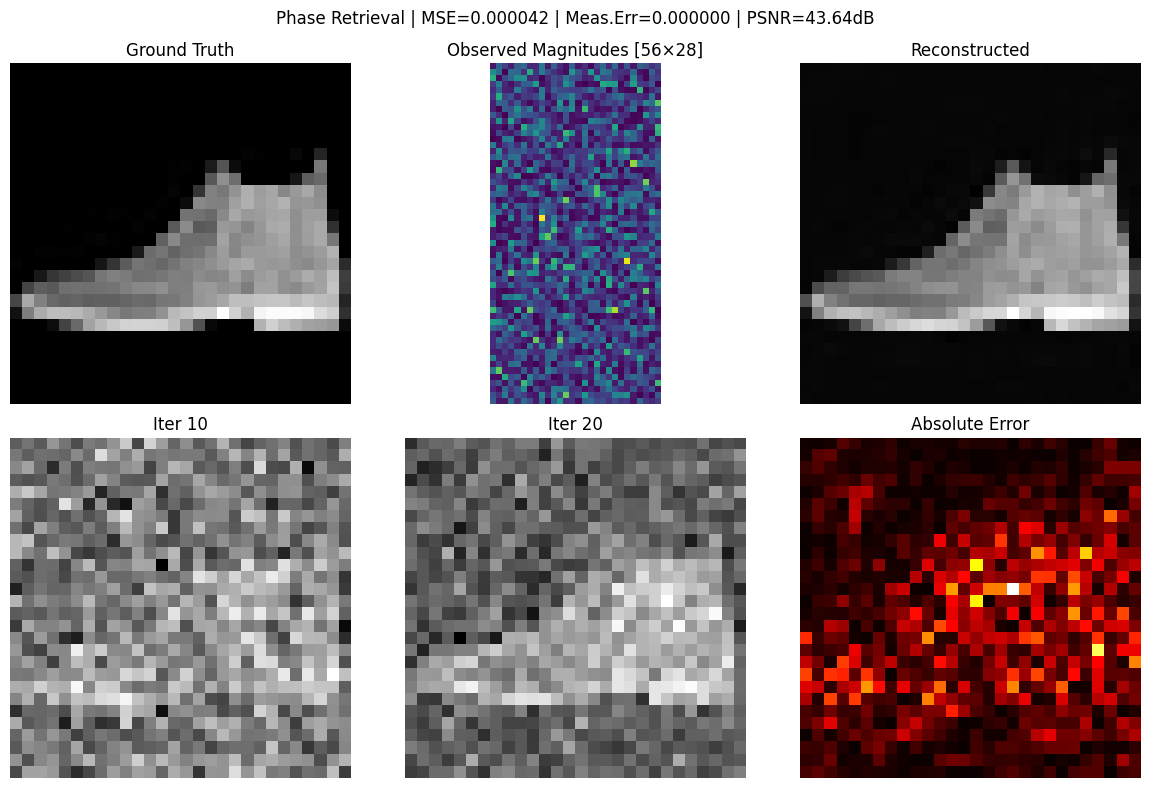

Saved convergence plot to outputs/fashionmnist/gaussian_pr/fashion_gaussian_pr_convergence_0.png


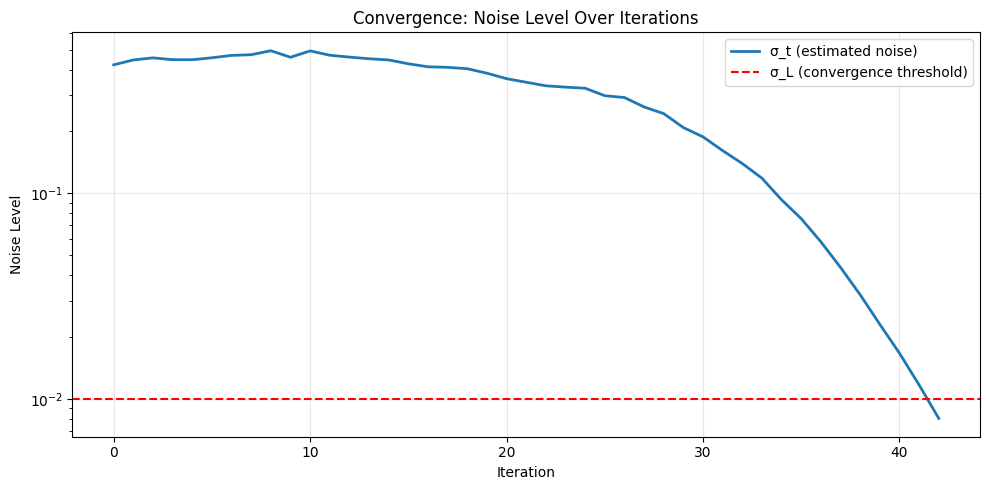

Saved reconstruction figure to outputs/fashionmnist/gaussian_pr/gaussian_pr_result_1000.png


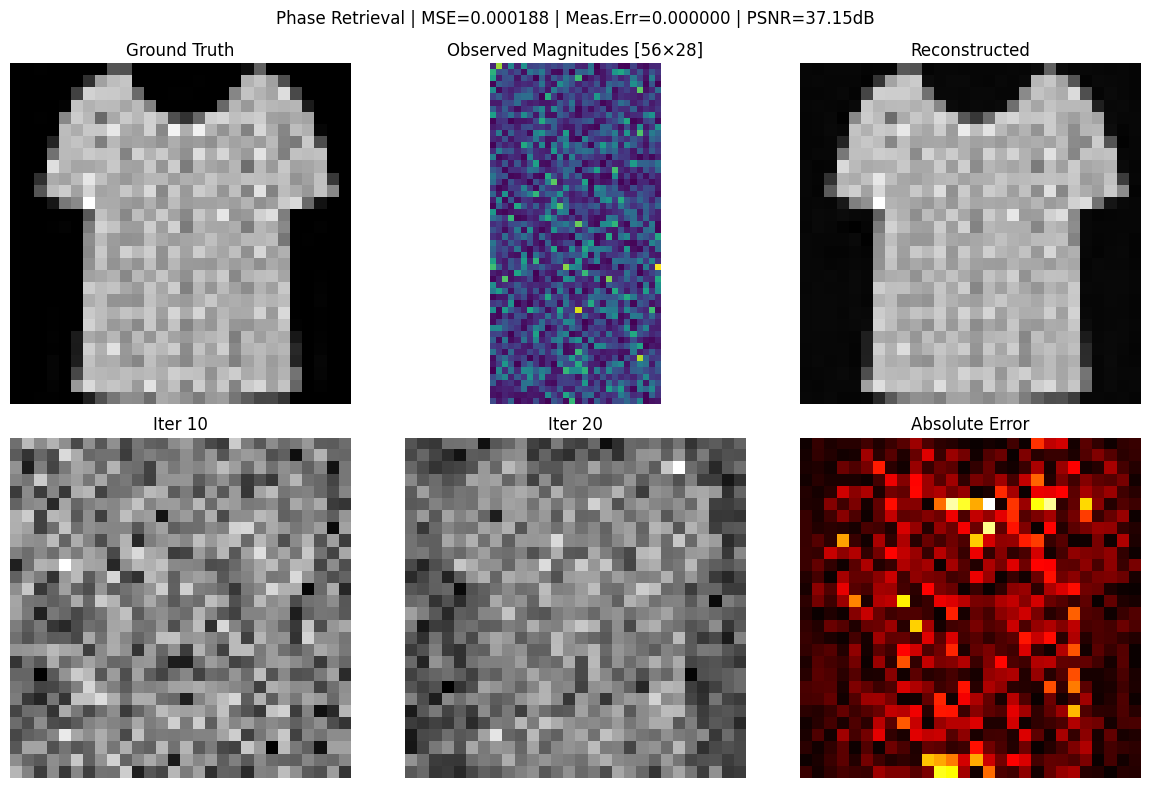

Saved convergence plot to outputs/fashionmnist/gaussian_pr/fashion_gaussian_pr_convergence_1000.png


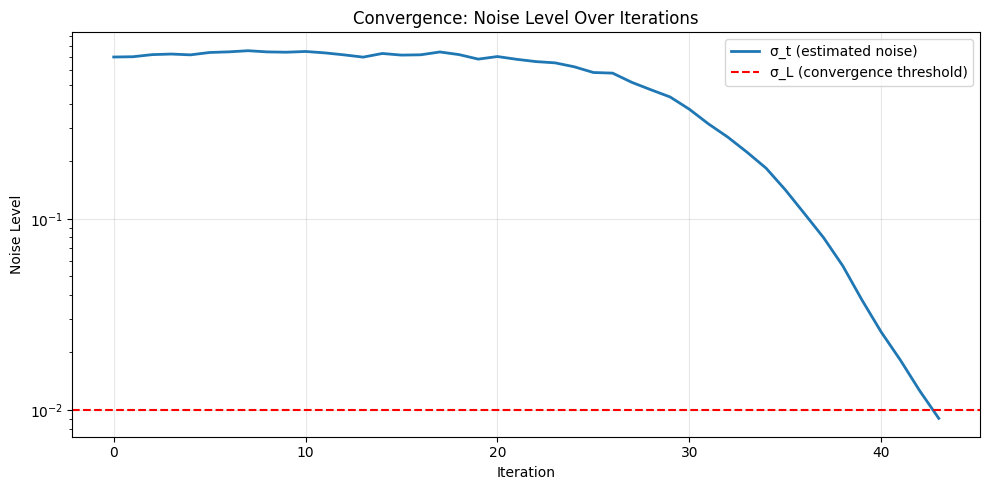

Saved reconstruction figure to outputs/fashionmnist/gaussian_pr/gaussian_pr_result_2000.png


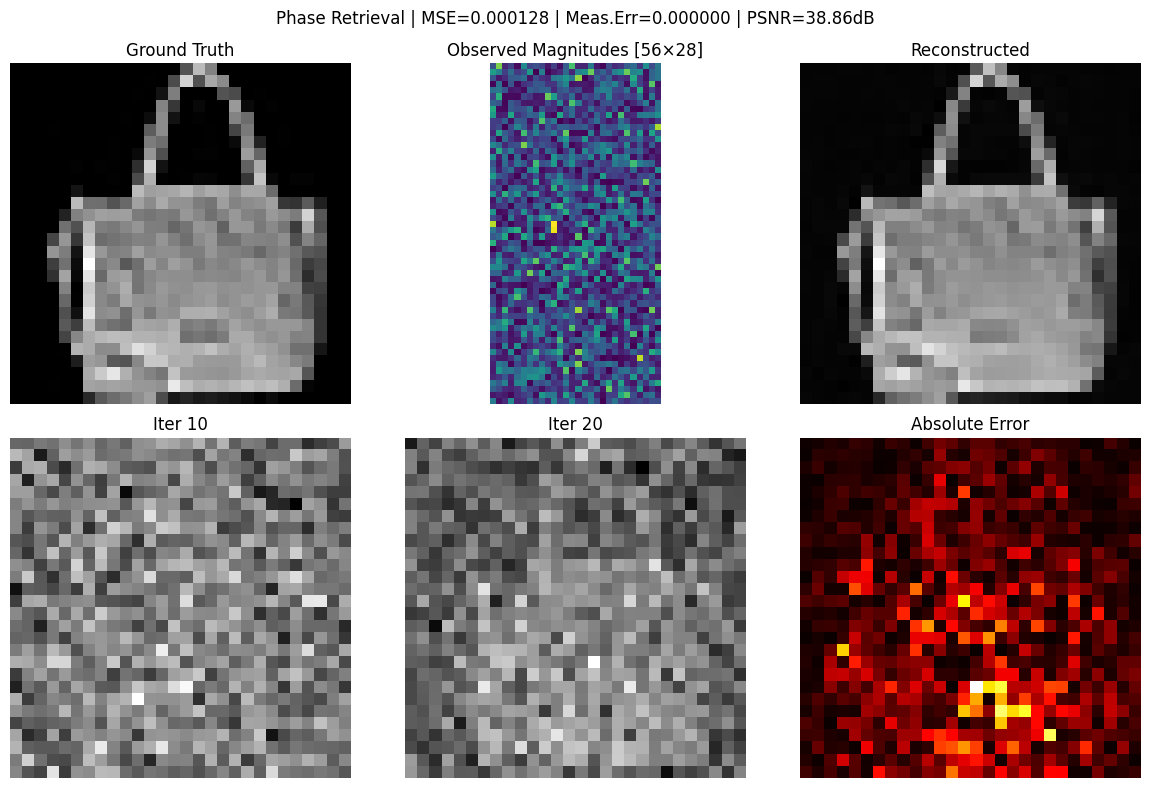

Saved convergence plot to outputs/fashionmnist/gaussian_pr/fashion_gaussian_pr_convergence_2000.png


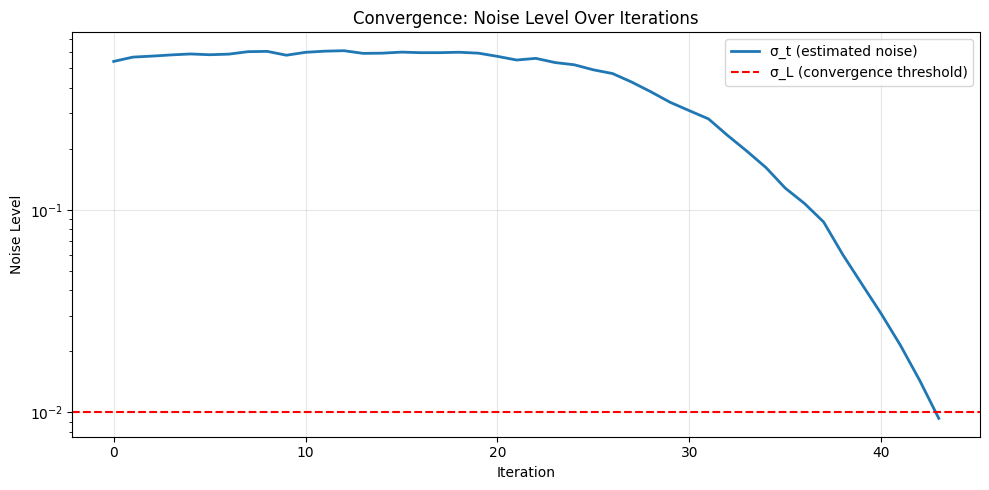


Gaussian Phase Retrieval Results for FashionMNIST (Best Config):
  Mean MSE: 0.000119
  Mean PSNR: 39.88 dB



In [8]:
# ========================================================================
# FashionMNIST: Gaussian Phase Retrieval - Final Evaluation with Best Config
# ========================================================================

# Run final evaluation with best config
print("--- Gaussian PR: Final Evaluation with Best Config ---")

gaussian_task_fashion = GaussianPhaseRetrievalTask(
    measurement_dim=gaussian_config_fashion.measurement_dim,
    image_dim=gaussian_config_fashion.n_pixels,
    device=gaussian_config_fashion.device
)

# Update config with best parameters
for key, value in best_gaussian_params_fashion.items():
    setattr(gaussian_config_fashion, key, value)

# Get test images
fashion_test_images_gaussian = [0, 1000, 2000]

# Run phase retrieval on best 3 images and save visualizations
gaussian_pr_dir_fashion = fashion_output_dir / 'gaussian_pr'
gaussian_pr_dir_fashion.mkdir(parents=True, exist_ok=True)

fashion_gaussian_metrics = {'mse': [], 'psnr': []}

for idx in fashion_test_images_gaussian:
    x_test, _ = test_dataset_fashion[idx]
    x_test_batch = x_test.view(-1).to(config.device)
    
    # Get measurements
    measurements = gaussian_task_fashion.get_magnitudes(x_test_batch)
    
    # Run phase retrieval with best config
    with torch.no_grad():
        x_recon, pr_results = phase_retrieval_with_gaussian_measurements(
            denoiser=fashion_denoiser,
            task=gaussian_task_fashion,
            measurements=measurements,
            config=gaussian_config_fashion
        )
        x_recon = x_recon.to(config.device)
    
    # Compute metrics
    eval_metrics = evaluate_reconstruction(x_test_batch, x_recon, gaussian_task_fashion, measurements)
    fashion_gaussian_metrics['mse'].append(eval_metrics['mse_image'])
    fashion_gaussian_metrics['psnr'].append(eval_metrics['psnr'])

    # Save visualization for this image
    visualize_reconstruction_results(
        x_test_batch.cpu(),
        x_recon.cpu(),
        measurement=measurements.cpu(),
        trajectory=pr_results['intermediates'],
        metrics=eval_metrics,
        save_path=gaussian_pr_dir_fashion / f'gaussian_pr_result_{idx}.png'
    )

    visualize_convergence(
        pr_results['sigma_trajectory'],
        gaussian_pr_dir_fashion / f'fashion_gaussian_pr_convergence_{idx}.png',
        sigma_L=gaussian_config_fashion.sigma_L
    )

print(f"\nGaussian Phase Retrieval Results for FashionMNIST (Best Config):")
print(f"  Mean MSE: {np.mean(fashion_gaussian_metrics['mse']):.6f}")
print(f"  Mean PSNR: {np.mean(fashion_gaussian_metrics['psnr']):.2f} dB\n")

# Store results
all_results.append({
    'dataset': 'FashionMNIST',
    'task': 'Gaussian PR',
    'mse': np.mean(fashion_gaussian_metrics['mse']),
    'psnr': np.mean(fashion_gaussian_metrics['psnr']),
    'config': best_gaussian_params_fashion
})

### FashionMNIST: Fourier Phase Retrieval

In [9]:
# ========================================================================
# FashionMNIST: Fourier Phase Retrieval - Hyperparameter Evaluation
# ========================================================================
print("="*80)
print("FashionMNIST - Fourier Phase Retrieval: Hyperparameter Evaluation")
print("="*80)

# Get Fourier config
fourier_config_fashion = config.get_fourier_config()

# Parameter ranges for sweep
fourier_param_ranges_fashion = {
    'beta': [0.01, 0.05, 0.1],
    'h0': [0.01, 0.05, 0.1],
    'sigma_L': [0.01],
}

# Run evaluation with parameter sweep
fashion_fourier_results = run_fourier_phase_retrieval_evaluation(
    denoiser=fashion_denoiser,
    val_dataset=test_dataset_fashion,
    config=fourier_config_fashion,
    param_ranges=fourier_param_ranges_fashion
)

# Find best configuration by PSNR
best_fourier_config_name_fashion = max(
    fashion_fourier_results.keys(),
    key=lambda k: fashion_fourier_results[k]['mean_psnr']
)
best_fourier_psnr_fashion = fashion_fourier_results[best_fourier_config_name_fashion]['mean_psnr']
best_fourier_params_fashion = fashion_fourier_results[best_fourier_config_name_fashion]['params']

# Transform results for summary table
fourier_summary_data_fashion = []
for config_name, res in fashion_fourier_results.items():
    row = {
        **{key: f"{value:.3f}" if isinstance(value, float) else str(value) for key, value in res['params'].items()},
        'Mean PSNR (dB)': f"{res['mean_psnr']:.2f}",
        'Mean Iterations': f"{res['mean_iterations']:.1f}"
    }
    fourier_summary_data_fashion.append(row)
fourier_summary_df_fashion = pd.DataFrame(fourier_summary_data_fashion).sort_values(by='Mean PSNR (dB)', ascending=False)
print("\nFourier Phase Retrieval Hyperparameter Evaluation Summary:")
print(fourier_summary_df_fashion.to_string(index=False))

print(f"\nBest Fourier Config for FashionMNIST:")
print(f"  {best_fourier_config_name_fashion}")
print(f"  Parameters: {best_fourier_params_fashion}")
print(f"  Mean PSNR: {best_fourier_psnr_fashion:.3f} dB\n")

FashionMNIST - Fourier Phase Retrieval: Hyperparameter Evaluation

Fourier Phase Retrieval Evaluation
Number of configurations: 9
Fourier Task: Image 28x28, Padded to 56x56
Measurements M: 3136, Image N: 784


[1/9] PSNR: 16.3943


[2/9] PSNR: 17.6288


[3/9] PSNR: 18.1796


[4/9] PSNR: 16.4898


[5/9] PSNR: 16.7056


[6/9] PSNR: 17.1360


[7/9] PSNR: 16.0432


[8/9] PSNR: 16.6831


[9/9] PSNR: 16.7337

Fourier Phase Retrieval Hyperparameter Evaluation Summary:
 beta    h0 sigma_L Mean PSNR (dB) Mean Iterations
0.010 0.100   0.010          18.18           252.4
0.010 0.050   0.010          17.63           270.9
0.050 0.100   0.010          17.14           240.6
0.100 0.100   0.010          16.73           208.1
0.050 0.050   0.010          16.71           262.2
0.100 0.050   0.010          16.68           228.4
0.050 0.010   0.010          16.49           331.2
0.010 0.010   0.010          16.39           359.9
0.100 0.010   0.010          16.04           323.0

Best Fourier Config for FashionMNIST:
  Config_02_beta=.0100_h0=.1000_sigma_L=.0100
  Parameters: {'beta': 0.01, 'h0': 0.1, 'sigma_L': 0.01}
  Mean PSNR: 18.180 dB



--- Fourier PR: Final Evaluation with Best Config ---
Fourier Task: Image 28x28, Padded to 56x56
Measurements M: 3136, Image N: 784
Saved reconstruction figure to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_0.png


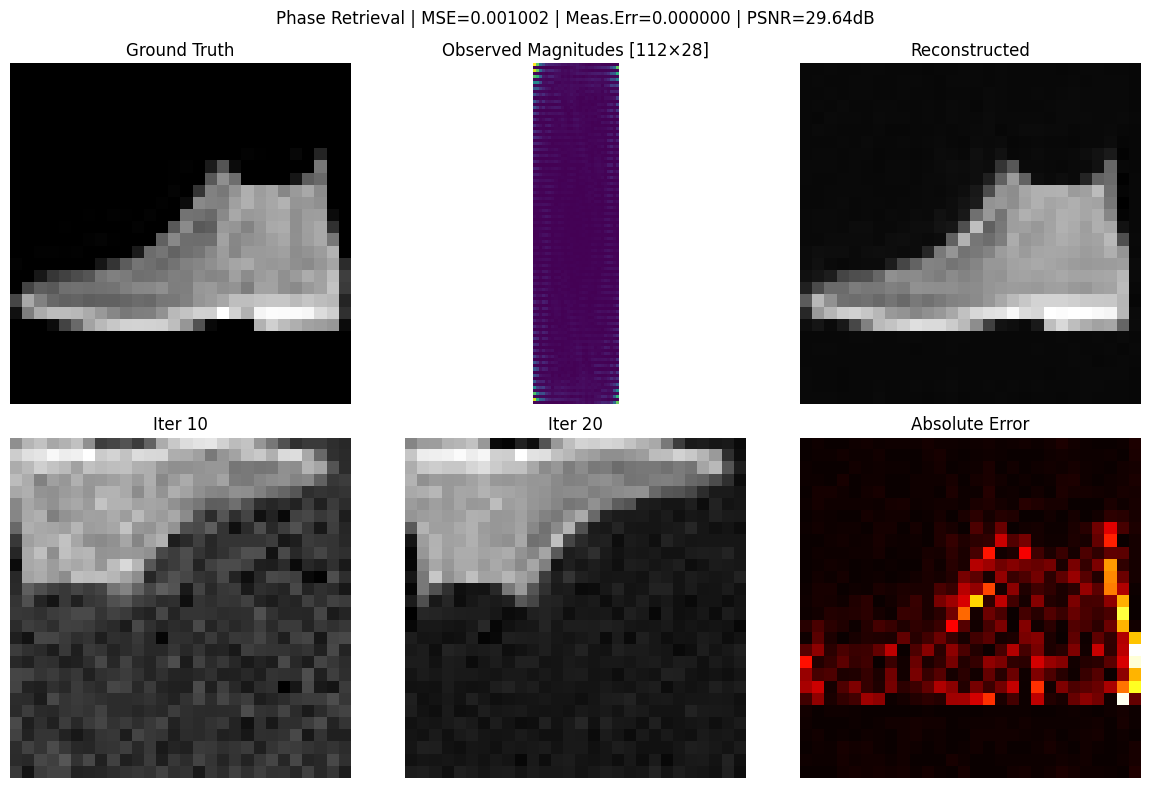

Saved convergence plot to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_convergence_0.png


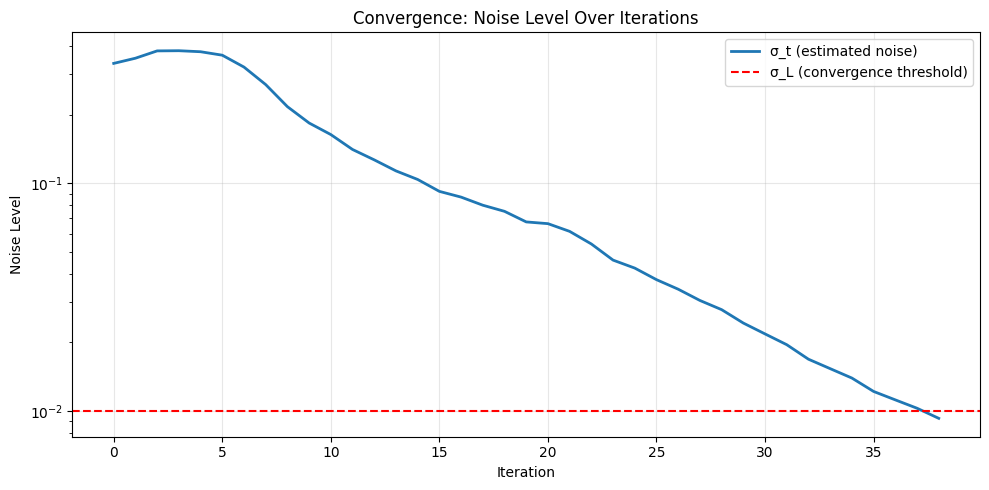

Saved reconstruction figure to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_1000.png


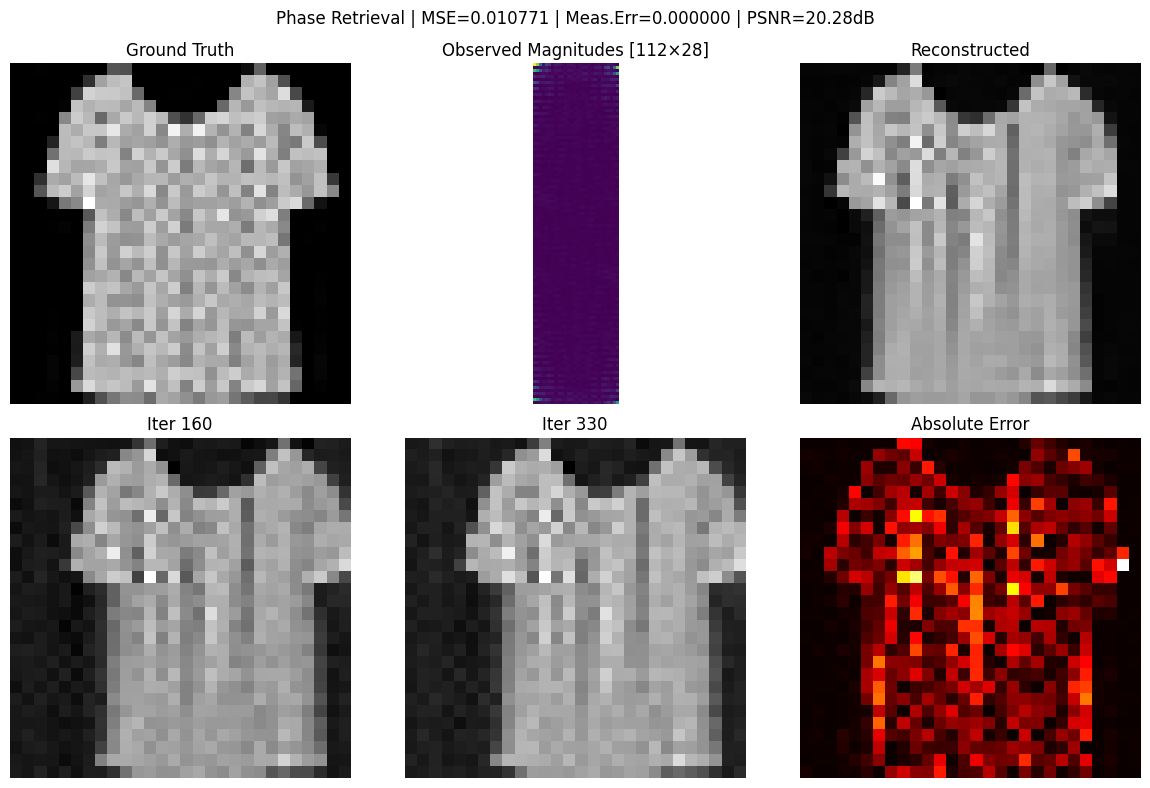

Saved convergence plot to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_convergence_1000.png


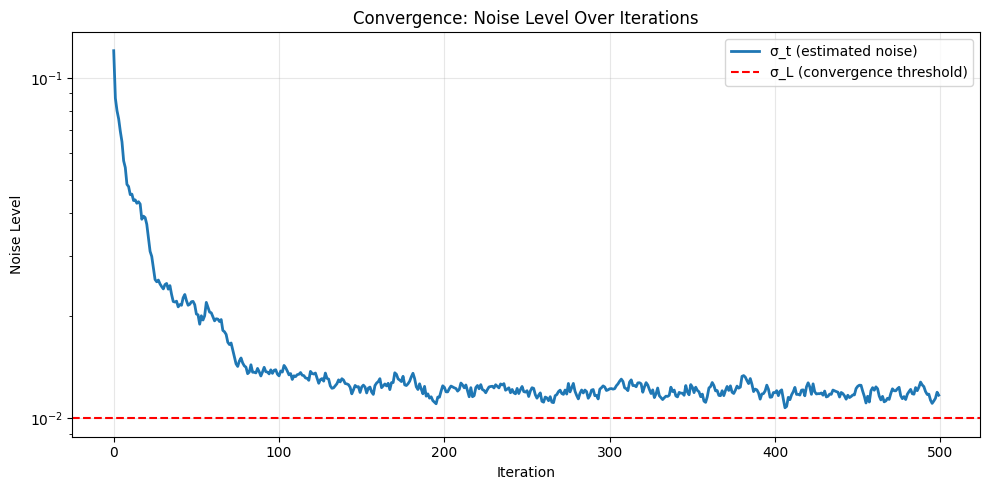

Saved reconstruction figure to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_2000.png


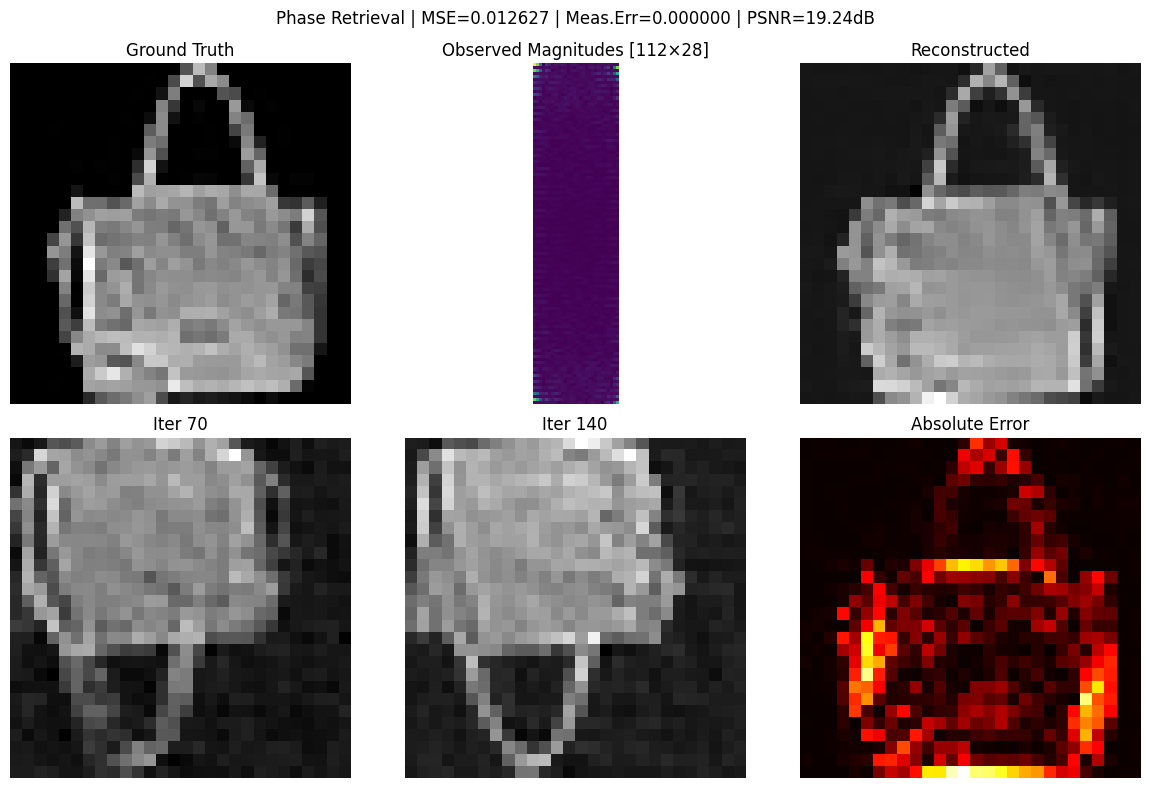

Saved convergence plot to outputs/fashionmnist/fourier_pr/fashion_fourier_pr_convergence_2000.png


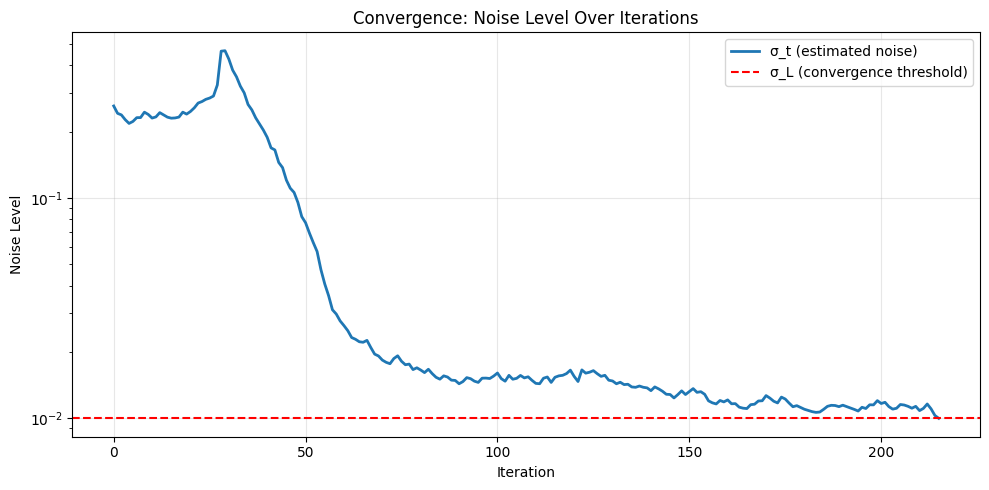


Fourier Phase Retrieval Results for FashionMNIST (Best Config):
  Mean MSE: 0.008133
  Mean PSNR: 23.06 dB



In [28]:
# ========================================================================
# FashionMNIST: Fourier Phase Retrieval - Final Evaluation with Best Config
# ========================================================================

# Run final evaluation with best config
print("--- Fourier PR: Final Evaluation with Best Config ---")

fourier_task_fashion = FourierPhaseRetrievalTask(
    image_size=fourier_config_fashion.image_size,
    oversample_ratio=fourier_config_fashion.oversample_ratio,
    device=fourier_config_fashion.device
)

# Update config with best parameters
for key, value in best_fourier_params_fashion.items():
    setattr(fourier_config_fashion, key, value)

# Get test images
fashion_test_images_fourier = [0, 1000, 2000]

# Run phase retrieval on best 3 images and save visualizations
fourier_pr_dir_fashion = fashion_output_dir / 'fourier_pr'
fourier_pr_dir_fashion.mkdir(parents=True, exist_ok=True)

fashion_fourier_metrics = {'mse': [], 'psnr': []}

for idx in fashion_test_images_fourier:
    x_test, _ = test_dataset_fashion[idx]
    x_test_batch = x_test.view(-1).to(config.device)
    
    # Get measurements
    measurements = fourier_task_fashion.get_magnitudes(x_test_batch)
    
    # Run phase retrieval with best config
    with torch.no_grad():
        x_recon, pr_results = phase_retrieval_with_fourier_measurements(
            denoiser=fashion_denoiser,
            task=fourier_task_fashion,
            measurements=measurements,
            config=fourier_config_fashion
        )
        x_recon = x_recon.to(config.device)
    
    # Align to handle ambiguities
    x_aligned, _ = align_fourier_reconstruction(
        x_recon=x_recon,
        x_test=x_test_batch,
        image_size=fourier_config_fashion.image_size
    )
    
    # Compute metrics
    eval_metrics = evaluate_reconstruction(x_test_batch, x_aligned, fourier_task_fashion, measurements)
    
    fashion_fourier_metrics['mse'].append(eval_metrics['mse_image'])
    fashion_fourier_metrics['psnr'].append(eval_metrics['psnr'])

    # Save visualization for this image
    visualize_reconstruction_results(
        x_test_batch.cpu().squeeze(),
        x_aligned.cpu().squeeze(),
        measurement=measurements.cpu(),
        trajectory=pr_results['intermediates'],
        metrics=eval_metrics,
        save_path=fourier_pr_dir_fashion / f'fashion_fourier_pr_{idx}.png'
    )

    visualize_convergence(
        pr_results['sigma_trajectory'],
        fourier_pr_dir_fashion / f'fashion_fourier_pr_convergence_{idx}.png',
        sigma_L=fourier_config_fashion.sigma_L
    )

print(f"\nFourier Phase Retrieval Results for FashionMNIST (Best Config):")
print(f"  Mean MSE: {np.mean(fashion_fourier_metrics['mse']):.6f}")
print(f"  Mean PSNR: {np.mean(fashion_fourier_metrics['psnr']):.2f} dB\n")

# Store results
all_results.append({
    'dataset': 'FashionMNIST',
    'task': 'Fourier PR',
    'mse': np.mean(fashion_fourier_metrics['mse']),
    'psnr': np.mean(fashion_fourier_metrics['psnr']),
    'config': best_fourier_params_fashion
})